#  Step 1: Data Preprocessing

In [1]:
import pandas as pd

# Read the CSV file .
df = pd.read_csv("C:/Users/HP/Downloads/india_housing_prices.csv")
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [2]:
# Display the number of rows and columns
print("Original dataset shape:", df.shape)

Original dataset shape: (250000, 23)


In [3]:
# CHECK FOR MISSING VALUES
# Count the missing values in every column
missing_values = df.isnull().sum()

In [4]:
# Display the missing-value count
print("\nMissing values in each column:")
print(missing_values)



Missing values in each column:
ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64


In [5]:
# Check the total number of duplicate rows
duplicate_count = df.duplicated().sum()

# Display the result
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [6]:
# Check the data type of every column
print(df.dtypes)

ID                                  int64
State                                 str
City                                  str
Locality                              str
Property_Type                         str
BHK                                 int64
Size_in_SqFt                        int64
Price_in_Lakhs                    float64
Price_per_SqFt                    float64
Year_Built                          int64
Furnished_Status                      str
Floor_No                            int64
Total_Floors                        int64
Age_of_Property                     int64
Nearby_Schools                      int64
Nearby_Hospitals                    int64
Public_Transport_Accessibility        str
Parking_Space                         str
Security                              str
Amenities                             str
Facing                                str
Owner_Type                            str
Availability_Status                   str
dtype: object


In [7]:
# List all categorical columns
categorical_columns = df.select_dtypes(include="object").columns

# Display unique values and number of unique values
for column in categorical_columns:
    print("\nColumn:", column)
    print("Number of unique values:", df[column].nunique())
    print("Unique values:", df[column].unique())


Column: State
Number of unique values: 20
Unique values: <ArrowStringArray>
[    'Tamil Nadu',    'Maharashtra',         'Punjab',      'Rajasthan',
    'West Bengal',   'Chhattisgarh',          'Delhi',      'Jharkhand',
      'Telangana',      'Karnataka',  'Uttar Pradesh',          'Assam',
    'Uttarakhand',          'Bihar',        'Gujarat',        'Haryana',
 'Andhra Pradesh', 'Madhya Pradesh',         'Kerala',         'Odisha']
Length: 20, dtype: str

Column: City
Number of unique values: 42
Unique values: <ArrowStringArray>
[       'Chennai',           'Pune',       'Ludhiana',        'Jodhpur',
         'Jaipur',       'Durgapur',     'Coimbatore',       'Bilaspur',
      'New Delhi',         'Ranchi',       'Warangal',      'Bangalore',
         'Nagpur',        'Lucknow',        'Silchar',       'Dehradun',
          'Noida',           'Gaya',     'Jamshedpur',      'Ahmedabad',
      'Hyderabad',      'Faridabad',       'Amritsar',        'Kolkata',
         'Dwarka', 'V

C:\Users\HP\AppData\Local\Temp\ipykernel_14988\1612249531.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


Number of unique values: 3
Unique values: <ArrowStringArray>
['Furnished', 'Unfurnished', 'Semi-furnished']
Length: 3, dtype: str

Column: Public_Transport_Accessibility
Number of unique values: 3
Unique values: <ArrowStringArray>
['High', 'Low', 'Medium']
Length: 3, dtype: str

Column: Parking_Space
Number of unique values: 2
Unique values: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

Column: Security
Number of unique values: 2
Unique values: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

Column: Amenities
Number of unique values: 325
Unique values: <ArrowStringArray>
['Playground, Gym, Garden, Pool, Clubhouse',
 'Playground, Clubhouse, Pool, Gym, Garden',
         'Clubhouse, Pool, Playground, Gym',
 'Playground, Clubhouse, Gym, Pool, Garden',
 'Playground, Garden, Gym, Pool, Clubhouse',
                    'Playground, Clubhouse',
            'Clubhouse, Garden, Playground',
         'Gym, Pool, Clubhouse, Playground',
            'Garden, Clubhouse, Playground',

In [8]:
# Convert lakhs to rupees without int32 overflow
df["Price_in_Lakhs"] = (df["Price_in_Lakhs"].astype("float64") * 100000).astype("int64")

# Check the result
print(df["Price_in_Lakhs"].head(10))
print(df["Price_in_Lakhs"].dtype)

0    48976000
1    19552000
2    18379000
3    30029000
4    18290000
5    13528000
6    31812000
7    14138999
8    18916000
9    18742000
Name: Price_in_Lakhs, dtype: int64
int64


In [9]:
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,48976000,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,19552000,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,18379000,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,30029000,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,18290000,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [10]:
# Find rows where Total_Floors is less than Floor_No
invalid_rows = df["Total_Floors"] < df["Floor_No"]

# Show how many invalid rows were found
print("Invalid rows before correction:", invalid_rows.sum())

# Change ONLY Total_Floors
# Floor_No values remain completely unchanged
df.loc[invalid_rows, "Total_Floors"] = df.loc[invalid_rows, "Floor_No"]

# Verify the correction
remaining_invalid = (df["Total_Floors"] < df["Floor_No"]).sum()

print("Invalid rows after correction:", remaining_invalid)

# Display Floor_No and Total_Floors to verify
print(df[["Floor_No", "Total_Floors"]].head(20))

Invalid rows before correction: 116304
Invalid rows after correction: 0
    Floor_No  Total_Floors
0         22            22
1         21            21
2         19            27
3         21            26
4          3             3
5         27            27
6         16            16
7         24            24
8         23            23
9          6            13
10         8            12
11         6            24
12         9             9
13        13            13
14        26            26
15         4             7
16        15            15
17        14            14
18        10            10
19        13            18


In [11]:
# Create one-hot encoded columns for each individual amenity
amenities = ["Playground", "Gym", "Garden", "Pool", "Clubhouse"]

# Create a separate 0/1 column for each amenity
for amenity in amenities:
    df[amenity] = df["Amenities"].str.contains(amenity, case=False, na=False).astype(int)

# Display the original Amenities column and the new sub-columns
print(df[["Amenities"] + amenities].head(10))

                                  Amenities  Playground  Gym  Garden  Pool  \
0  Playground, Gym, Garden, Pool, Clubhouse           1    1       1     1   
1  Playground, Clubhouse, Pool, Gym, Garden           1    1       1     1   
2          Clubhouse, Pool, Playground, Gym           1    1       0     1   
3  Playground, Clubhouse, Gym, Pool, Garden           1    1       1     1   
4  Playground, Garden, Gym, Pool, Clubhouse           1    1       1     1   
5                     Playground, Clubhouse           1    0       0     0   
6             Clubhouse, Garden, Playground           1    0       1     0   
7          Gym, Pool, Clubhouse, Playground           1    1       0     1   
8             Garden, Clubhouse, Playground           1    0       1     0   
9        Clubhouse, Playground, Garden, Gym           1    1       1     0   

   Clubhouse  
0          1  
1          1  
2          1  
3          1  
4          1  
5          1  
6          1  
7          1  
8     

In [12]:
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Security,Amenities,Facing,Owner_Type,Availability_Status,Playground,Gym,Garden,Pool,Clubhouse
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,48976000,0.10,1990,...,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move,1,1,1,1,1
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,19552000,0.08,2008,...,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction,1,1,1,1,1
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,18379000,0.05,1997,...,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move,1,1,0,1,1
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,30029000,0.11,1991,...,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move,1,1,1,1,1
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,18290000,0.04,2002,...,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move,1,1,1,1,1


In [13]:
# AMENITY->

# List of individual amenity columns
amenity_columns = ["Playground", "Gym", "Garden", "Pool", "Clubhouse"]

# Count how many amenities each property has
df["Amenity_Count"] = df[amenity_columns].sum(axis=1)

# Check the result
print(df[amenity_columns + ["Amenity_Count"]].head(10))

   Playground  Gym  Garden  Pool  Clubhouse  Amenity_Count
0           1    1       1     1          1              5
1           1    1       1     1          1              5
2           1    1       0     1          1              4
3           1    1       1     1          1              5
4           1    1       1     1          1              5
5           1    0       0     0          1              2
6           1    0       1     0          1              3
7           1    1       0     1          1              4
8           1    0       1     0          1              3
9           1    1       1     0          1              4


In [14]:
#LOCALITY-> 

# Calculate the frequency of each locality
locality_frequency = df["Locality"].value_counts()

# Replace each locality with its frequency
df["Locality_Frequency"] = df["Locality"].map(locality_frequency)

# Display the original locality and its frequency
print(df[["Locality", "Locality_Frequency"]].head(10))

       Locality  Locality_Frequency
0   Locality_84                 484
1  Locality_490                 515
2  Locality_167                 510
3  Locality_393                 529
4  Locality_466                 512
5  Locality_246                 510
6  Locality_254                 536
7  Locality_490                 515
8  Locality_232                 527
9  Locality_122                 504


In [15]:
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Facing,Owner_Type,Availability_Status,Playground,Gym,Garden,Pool,Clubhouse,Amenity_Count,Locality_Frequency
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,48976000,0.10,1990,...,West,Owner,Ready_to_Move,1,1,1,1,1,5,484
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,19552000,0.08,2008,...,North,Builder,Under_Construction,1,1,1,1,1,5,515
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,18379000,0.05,1997,...,South,Broker,Ready_to_Move,1,1,0,1,1,4,510
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,30029000,0.11,1991,...,North,Builder,Ready_to_Move,1,1,1,1,1,5,529
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,18290000,0.04,2002,...,East,Builder,Ready_to_Move,1,1,1,1,1,5,512


In [16]:
# List of numerical columns that we want to validate
numerical_columns = [
    "BHK",
    "Size_in_SqFt",
    "Price_in_Lakhs",
    "Price_per_SqFt",
    "Year_Built",
    "Age_of_Property",
    "Floor_No",
    "Total_Floors",
    "Nearby_Schools",
    "Nearby_Hospitals"
]

# Check the minimum value of every numerical column
# This helps us identify zero or negative values
print("Minimum value of each numerical column:")
print(df[numerical_columns].min())

Minimum value of each numerical column:
BHK                       1.0
Size_in_SqFt            500.0
Price_in_Lakhs      1000000.0
Price_per_SqFt            0.0
Year_Built             1990.0
Age_of_Property           2.0
Floor_No                  0.0
Total_Floors              1.0
Nearby_Schools            1.0
Nearby_Hospitals          1.0
dtype: float64


In [17]:
# Count how many properties have Price_per_SqFt equal to 0
zero_price_per_sqft = (df["Price_per_SqFt"] == 0).sum()

# Display the number of zero values
print("Number of Price_per_SqFt values equal to 0:", zero_price_per_sqft)

# Display those rows for inspection
print("\nRows with Price_per_SqFt = 0:")
print(df[df["Price_per_SqFt"] == 0][
    ["Price_in_Lakhs", "Size_in_SqFt", "Price_per_SqFt"]
].head(20))

Number of Price_per_SqFt values equal to 0: 2534

Rows with Price_per_SqFt = 0:
      Price_in_Lakhs  Size_in_SqFt  Price_per_SqFt
190          1162000          4467             0.0
214          1701000          3471             0.0
272          2101000          4497             0.0
356          1280000          3498             0.0
387          1834000          4775             0.0
551          1567000          3438             0.0
596          1889000          4453             0.0
654          1473000          4479             0.0
1023         1030000          2888             0.0
1133         1780000          4718             0.0
1167         1138000          2441             0.0
1190         1773999          4435             0.0
1362         1362000          3277             0.0
1381         1305000          3063             0.0
1425         1329000          3720             0.0
1432         1623000          3918             0.0
1440         1487000          4597             0.0
15

In [18]:
# Calculate Price_per_SqFt independently from the current
# Price_in_Lakhs (which is now stored in rupees) and property size.
calculated_price_per_sqft = (
    df["Price_in_Lakhs"] / df["Size_in_SqFt"]
)

# Display the original and newly calculated values
# for the rows where the original Price_per_SqFt is 0.
check_price = df[df["Price_per_SqFt"] == 0][
    ["Price_in_Lakhs", "Size_in_SqFt", "Price_per_SqFt"]
].copy()

# Add the calculated value temporarily for verification
check_price["Calculated_Price_per_SqFt"] = calculated_price_per_sqft[
    df["Price_per_SqFt"] == 0
]

# Display the first 20 rows
print(check_price.head(20))

      Price_in_Lakhs  Size_in_SqFt  Price_per_SqFt  Calculated_Price_per_SqFt
190          1162000          4467             0.0                 260.129841
214          1701000          3471             0.0                 490.060501
272          2101000          4497             0.0                 467.200356
356          1280000          3498             0.0                 365.923385
387          1834000          4775             0.0                 384.083770
551          1567000          3438             0.0                 455.788249
596          1889000          4453             0.0                 424.208399
654          1473000          4479             0.0                 328.868051
1023         1030000          2888             0.0                 356.648199
1133         1780000          4718             0.0                 377.278508
1167         1138000          2441             0.0                 466.202376
1190         1773999          4435             0.0              

In [19]:
# Calculate Price_per_SqFt independently using price and property size
calculated_price_per_sqft = (
    df["Price_in_Lakhs"] / df["Size_in_SqFt"]
)

# Calculate the difference between the existing value
# and the independently calculated value
difference = (
    df["Price_per_SqFt"] - calculated_price_per_sqft
)

# Show some rows where the original Price_per_SqFt is not zero
# so we can compare the values
comparison = df[df["Price_per_SqFt"] != 0][
    ["Price_in_Lakhs", "Size_in_SqFt", "Price_per_SqFt"]
].copy()

# Add the independently calculated value
comparison["Calculated_Price_per_SqFt"] = calculated_price_per_sqft[
    df["Price_per_SqFt"] != 0
]

# Add the difference between the two values
comparison["Difference"] = difference[
    df["Price_per_SqFt"] != 0
]

# Display the first 20 rows
print(comparison.head(20))

    Price_in_Lakhs  Size_in_SqFt  Price_per_SqFt  Calculated_Price_per_SqFt  \
0         48976000          4740            0.10               10332.489451   
1         19552000          2364            0.08                8270.727580   
2         18379000          3642            0.05                5046.403075   
3         30029000          2741            0.11               10955.490697   
4         18290000          4823            0.04                3792.245490   
5         13528000          3500            0.04                3865.142857   
6         31812000          4826            0.07                6591.794447   
7         14138999          4252            0.03                3325.258467   
8         18916000          2678            0.07                7063.480209   
9         18742000          1393            0.13               13454.414932   
10        32424000           665            0.49               48757.894737   
11        46538000          3988            0.12    

In [20]:
# Recalculate Price_per_SqFt using the current price in rupees
# divided by the property size in square feet.
df["Price_per_SqFt"] = (
    df["Price_in_Lakhs"] / df["Size_in_SqFt"]
)

# Display the first 10 rows to verify the new values
print(df[[
    "Price_in_Lakhs",
    "Size_in_SqFt",
    "Price_per_SqFt"
]].head(10))

# Check the minimum and maximum after correction
print("\nMinimum Price_per_SqFt:",
      df["Price_per_SqFt"].min())

print("Maximum Price_per_SqFt:",
      df["Price_per_SqFt"].max())

   Price_in_Lakhs  Size_in_SqFt  Price_per_SqFt
0        48976000          4740    10332.489451
1        19552000          2364     8270.727580
2        18379000          3642     5046.403075
3        30029000          2741    10955.490697
4        18290000          4823     3792.245490
5        13528000          3500     3865.142857
6        31812000          4826     6591.794447
7        14138999          4252     3325.258467
8        18916000          2678     7063.480209
9        18742000          1393    13454.414932

Minimum Price_per_SqFt: 202.24719101123594
Maximum Price_per_SqFt: 99182.0


In [21]:
# Check for zero or negative values in Price_per_SqFt
invalid_price_per_sqft = (
    df["Price_per_SqFt"] <= 0
).sum()

# Display the result
print("Zero or negative Price_per_SqFt values:",
      invalid_price_per_sqft)

Zero or negative Price_per_SqFt values: 0


In [22]:
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Facing,Owner_Type,Availability_Status,Playground,Gym,Garden,Pool,Clubhouse,Amenity_Count,Locality_Frequency
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,48976000,10332.489451,1990,...,West,Owner,Ready_to_Move,1,1,1,1,1,5,484
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,19552000,8270.727580,2008,...,North,Builder,Under_Construction,1,1,1,1,1,5,515
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,18379000,5046.403075,1997,...,South,Broker,Ready_to_Move,1,1,0,1,1,4,510
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,30029000,10955.490697,1991,...,North,Builder,Ready_to_Move,1,1,1,1,1,5,529
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,18290000,3792.245490,2002,...,East,Builder,Ready_to_Move,1,1,1,1,1,5,512


In [23]:
# List all categorical columns
categorical_columns = [
    "State",
    "City",
    "Locality",
    "Property_Type",
    "Furnished_Status",
    "Public_Transport_Accessibility",
    "Parking_Space",
    "Security",
    "Facing",
    "Owner_Type",
    "Availability_Status"
]

# Display the number of unique values in each categorical column
print("Number of unique values:")
print(df[categorical_columns].nunique())

# Display the actual unique values for each categorical column
for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())

Number of unique values:
State                              20
City                               42
Locality                          500
Property_Type                       3
Furnished_Status                    3
Public_Transport_Accessibility      3
Parking_Space                       2
Security                            2
Facing                              4
Owner_Type                          3
Availability_Status                 2
dtype: int64

State:
<ArrowStringArray>
[    'Tamil Nadu',    'Maharashtra',         'Punjab',      'Rajasthan',
    'West Bengal',   'Chhattisgarh',          'Delhi',      'Jharkhand',
      'Telangana',      'Karnataka',  'Uttar Pradesh',          'Assam',
    'Uttarakhand',          'Bihar',        'Gujarat',        'Haryana',
 'Andhra Pradesh', 'Madhya Pradesh',         'Kerala',         'Odisha']
Length: 20, dtype: str

City:
<ArrowStringArray>
[       'Chennai',           'Pune',       'Ludhiana',        'Jodhpur',
         'Jaipur',       'Durg

In [24]:
# Convert Parking_Space from Yes/No to 1/0
df["Parking_Space"] = df["Parking_Space"].map({
    "Yes": 1,
    "No": 0
})

# Convert Security from Yes/No to 1/0
df["Security"] = df["Security"].map({
    "Yes": 1,
    "No": 0
})

# Convert Availability_Status into a binary value
# Ready_to_Move = 1
# Under_Construction = 0
df["Availability_Status"] = df["Availability_Status"].map({
    "Ready_to_Move": 1,
    "Under_Construction": 0
})

# Display the converted columns
print(df[[
    "Parking_Space",
    "Security",
    "Availability_Status"
]].head(10))

# Check the unique values after encoding
print("\nUnique values after encoding:")

print("Parking_Space:",
      df["Parking_Space"].unique())

print("Security:",
      df["Security"].unique())

print("Availability_Status:",
      df["Availability_Status"].unique())

   Parking_Space  Security  Availability_Status
0              0         0                    1
1              0         1                    0
2              1         0                    1
3              1         1                    1
4              0         1                    1
5              1         1                    1
6              0         1                    0
7              1         1                    0
8              0         1                    0
9              1         0                    1

Unique values after encoding:
Parking_Space: [0 1]
Security: [0 1]
Availability_Status: [1 0]


In [25]:
# Display the binary encoded columns
print(df[[
    "Parking_Space",
    "Security",
    "Availability_Status"
]].head())

   Parking_Space  Security  Availability_Status
0              0         0                    1
1              0         1                    0
2              1         0                    1
3              1         1                    1
4              0         1                    1


In [26]:
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Facing,Owner_Type,Availability_Status,Playground,Gym,Garden,Pool,Clubhouse,Amenity_Count,Locality_Frequency
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,48976000,10332.489451,1990,...,West,Owner,1,1,1,1,1,1,5,484
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,19552000,8270.727580,2008,...,North,Builder,0,1,1,1,1,1,5,515
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,18379000,5046.403075,1997,...,South,Broker,1,1,1,0,1,1,4,510
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,30029000,10955.490697,1991,...,North,Builder,1,1,1,1,1,1,5,529
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,18290000,3792.245490,2002,...,East,Builder,1,1,1,1,1,1,5,512


In [27]:
# Calculate the correlation between Year_Built and Age_of_Property
correlation = df["Year_Built"].corr(df["Age_of_Property"])

# Display the correlation
print("Correlation between Year_Built and Age_of_Property:",
      correlation)

Correlation between Year_Built and Age_of_Property: -0.9999999999999988


In [28]:
# Step 1: Keep the original Furnished_Status column unchanged
print("Original Furnished_Status:")
print(df["Furnished_Status"].head(10))


# Step 2: Create one-hot encoded columns separately
furnished_encoded = pd.get_dummies(
    df["Furnished_Status"],
    prefix="Furnished_Status",
    dtype=int
)


# Step 3: Combine the original column and the new encoded columns
df = pd.concat(
    [df, furnished_encoded],
    axis=1
)


# Step 4: Display both the original column and encoded columns
print("\nOriginal + One-Hot Encoded:")
print(
    df[[
        "Furnished_Status",
        "Furnished_Status_Furnished",
        "Furnished_Status_Unfurnished",
        "Furnished_Status_Semi-furnished"
    ]].head(10)
)

Original Furnished_Status:
0         Furnished
1       Unfurnished
2    Semi-furnished
3         Furnished
4    Semi-furnished
5    Semi-furnished
6         Furnished
7       Unfurnished
8    Semi-furnished
9       Unfurnished
Name: Furnished_Status, dtype: str

Original + One-Hot Encoded:
  Furnished_Status  Furnished_Status_Furnished  Furnished_Status_Unfurnished  \
0        Furnished                           1                             0   
1      Unfurnished                           0                             1   
2   Semi-furnished                           0                             0   
3        Furnished                           1                             0   
4   Semi-furnished                           0                             0   
5   Semi-furnished                           0                             0   
6        Furnished                           1                             0   
7      Unfurnished                           0                       

In [29]:
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Playground,Gym,Garden,Pool,Clubhouse,Amenity_Count,Locality_Frequency,Furnished_Status_Furnished,Furnished_Status_Semi-furnished,Furnished_Status_Unfurnished
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,48976000,10332.489451,1990,...,1,1,1,1,1,5,484,1,0,0
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,19552000,8270.727580,2008,...,1,1,1,1,1,5,515,0,0,1
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,18379000,5046.403075,1997,...,1,1,0,1,1,4,510,0,1,0
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,30029000,10955.490697,1991,...,1,1,1,1,1,5,529,1,0,0
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,18290000,3792.245490,2002,...,1,1,1,1,1,5,512,0,1,0


In [30]:
#Property_Type->

# Remove all previously created Property_Type encoded columns.
# This prevents duplicate columns from being created.
property_columns = [
    "Property_Type_Apartment",
    "Property_Type_Independent House",
    "Property_Type_Villa"
]

df = df.drop(
    columns=[col for col in property_columns if col in df.columns]
)

# Create the one-hot encoded columns only once.
property_encoded = pd.get_dummies(
    df["Property_Type"],
    prefix="Property_Type",
    dtype=int
)

# Add the encoded columns to the dataframe.
df = pd.concat(
    [df, property_encoded],
    axis=1
)

# Display the original column and encoded columns once.
print(df[[
    "Property_Type",
    "Property_Type_Apartment",
    "Property_Type_Independent House",
    "Property_Type_Villa"
]].head(10))

       Property_Type  Property_Type_Apartment  \
0          Apartment                        1   
1  Independent House                        0   
2          Apartment                        1   
3  Independent House                        0   
4              Villa                        0   
5          Apartment                        1   
6  Independent House                        0   
7  Independent House                        0   
8              Villa                        0   
9              Villa                        0   

   Property_Type_Independent House  Property_Type_Villa  
0                                0                    0  
1                                1                    0  
2                                0                    0  
3                                1                    0  
4                                0                    1  
5                                0                    0  
6                                1                    

In [31]:
#Public_Transport_Accessibility->

# Create one-hot encoded columns for Public_Transport_Accessibility
transport_encoded = pd.get_dummies(
    df["Public_Transport_Accessibility"],
    prefix="Public_Transport_Accessibility",
    dtype=int
)

# Add the encoded columns to the dataframe
df = pd.concat(
    [df, transport_encoded],
    axis=1
)

# Display original column and encoded columns together
print(df[[
    "Public_Transport_Accessibility",
    "Public_Transport_Accessibility_High",
    "Public_Transport_Accessibility_Low",
    "Public_Transport_Accessibility_Medium"
]].head(10))

  Public_Transport_Accessibility  Public_Transport_Accessibility_High  \
0                           High                                    1   
1                            Low                                    0   
2                            Low                                    0   
3                           High                                    1   
4                            Low                                    0   
5                            Low                                    0   
6                           High                                    1   
7                           High                                    1   
8                            Low                                    0   
9                           High                                    1   

   Public_Transport_Accessibility_Low  Public_Transport_Accessibility_Medium  
0                                   0                                      0  
1                                   1 

In [32]:
#FACING->

# Create one-hot encoded columns for Facing
facing_encoded = pd.get_dummies(
    df["Facing"],
    prefix="Facing",
    dtype=int
)

# Add the encoded columns to the dataframe
df = pd.concat(
    [df, facing_encoded],
    axis=1
)

# Display original column and encoded columns together
print(df[[
    "Facing",
    "Facing_East",
    "Facing_North",
    "Facing_South",
    "Facing_West"
]].head(10))

  Facing  Facing_East  Facing_North  Facing_South  Facing_West
0   West            0             0             0            1
1  North            0             1             0            0
2  South            0             0             1            0
3  North            0             1             0            0
4   East            1             0             0            0
5   West            0             0             0            1
6  North            0             1             0            0
7  North            0             1             0            0
8  South            0             0             1            0
9   East            1             0             0            0


In [33]:
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Property_Type_Apartment,Property_Type_Independent House,Property_Type_Villa,Public_Transport_Accessibility_High,Public_Transport_Accessibility_Low,Public_Transport_Accessibility_Medium,Facing_East,Facing_North,Facing_South,Facing_West
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,48976000,10332.489451,1990,...,1,0,0,1,0,0,0,0,0,1
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,19552000,8270.727580,2008,...,0,1,0,0,1,0,0,1,0,0
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,18379000,5046.403075,1997,...,1,0,0,0,1,0,0,0,1,0
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,30029000,10955.490697,1991,...,0,1,0,1,0,0,0,1,0,0
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,18290000,3792.245490,2002,...,0,0,1,0,1,0,1,0,0,0


In [34]:
#OWNER_TYPE->

# Create one-hot encoded columns for Owner_Type
owner_encoded = pd.get_dummies(
    df["Owner_Type"],
    prefix="Owner_Type",
    dtype=int
)

# Add the encoded columns to the dataframe
df = pd.concat(
    [df, owner_encoded],
    axis=1
)

# Display the original column and encoded columns together
print(df[[
    "Owner_Type",
    "Owner_Type_Owner",
    "Owner_Type_Builder",
    "Owner_Type_Broker"
]].head(10))

  Owner_Type  Owner_Type_Owner  Owner_Type_Builder  Owner_Type_Broker
0      Owner                 1                   0                  0
1    Builder                 0                   1                  0
2     Broker                 0                   0                  1
3    Builder                 0                   1                  0
4    Builder                 0                   1                  0
5     Broker                 0                   0                  1
6    Builder                 0                   1                  0
7    Builder                 0                   1                  0
8     Broker                 0                   0                  1
9      Owner                 1                   0                  0


In [35]:
# Display the shape of the dataframe
print("Dataset shape:", df.shape)

# Display all column names
print("\nColumns:")
print(df.columns.tolist())

# Check the data types of all columns
print("\nData types:")
print(df.dtypes)

Dataset shape: (250000, 46)

Columns:
['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status', 'Playground', 'Gym', 'Garden', 'Pool', 'Clubhouse', 'Amenity_Count', 'Locality_Frequency', 'Furnished_Status_Furnished', 'Furnished_Status_Semi-furnished', 'Furnished_Status_Unfurnished', 'Property_Type_Apartment', 'Property_Type_Independent House', 'Property_Type_Villa', 'Public_Transport_Accessibility_High', 'Public_Transport_Accessibility_Low', 'Public_Transport_Accessibility_Medium', 'Facing_East', 'Facing_North', 'Facing_South', 'Facing_West', 'Owner_Type_Broker', 'Owner_Type_Builder', 'Owner_Type_Owner']

Data types:
ID                                         int64
State                         

# Step 2: Exploratory Data Analysis (EDA)


 Price & Size Analysis

Property Price Statistics
-------------------------
Mean Price   : ₹25,458,685.35
Median Price : ₹25,387,000.00
Minimum Price: ₹1,000,000.00
Maximum Price: ₹50,000,000.00


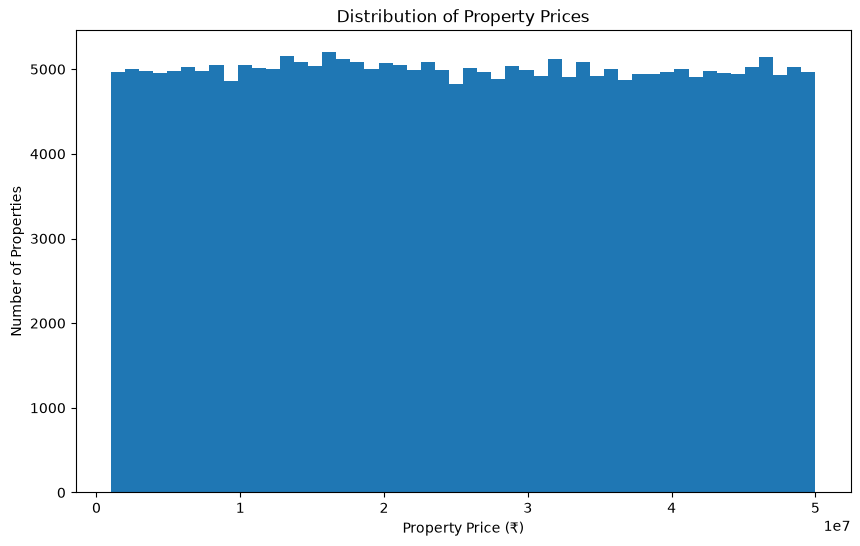

In [36]:
#1-What is the distribution of property prices?

'''Understand how property prices are distributed across the 250,000 properties.'''

import numpy as np              
import pandas as pd            
import matplotlib.pyplot as plt  
import seaborn as sns         

# Calculate basic price statistics
mean_price = df["Price_in_Lakhs"].mean()
median_price = df["Price_in_Lakhs"].median()
min_price = df["Price_in_Lakhs"].min()
max_price = df["Price_in_Lakhs"].max()

# Display the statistics
print("Property Price Statistics")
print("-------------------------")
print(f"Mean Price   : ₹{mean_price:,.2f}")
print(f"Median Price : ₹{median_price:,.2f}")
print(f"Minimum Price: ₹{min_price:,.2f}")
print(f"Maximum Price: ₹{max_price:,.2f}")

# Create the histogram
plt.figure(figsize=(10, 6))

plt.hist(
    df["Price_in_Lakhs"],
    bins=50
)

# Add title and labels
plt.title("Distribution of Property Prices")
plt.xlabel("Property Price (₹)")
plt.ylabel("Number of Properties")

# Display the graph
plt.show()

Property Size Statistics
------------------------
Mean Size   : 2,749.81 SqFt
Median Size : 2,747.00 SqFt
Minimum Size: 500.00 SqFt
Maximum Size: 5,000.00 SqFt


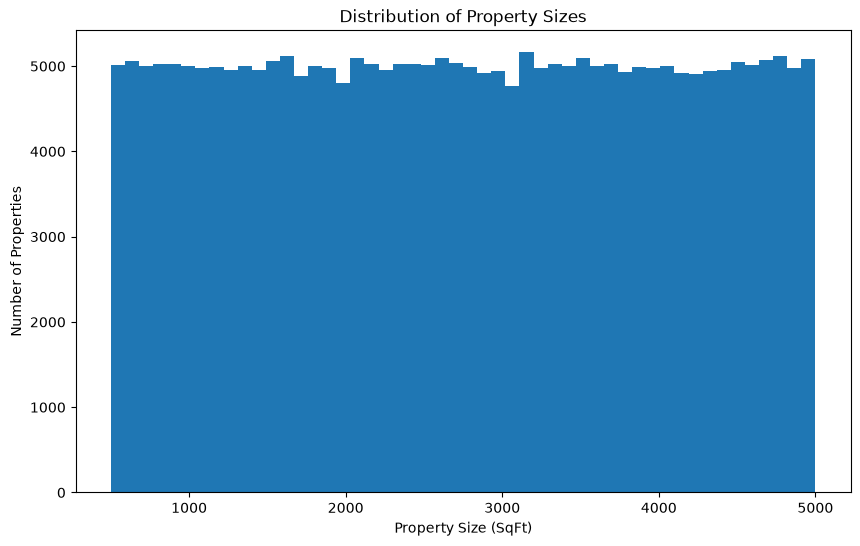

In [37]:
#2-What is the distribution of property sizes?

'''Understand the distribution of property sizes in square feet.'''

# Calculate basic size statistics
mean_size = df["Size_in_SqFt"].mean()
median_size = df["Size_in_SqFt"].median()
min_size = df["Size_in_SqFt"].min()
max_size = df["Size_in_SqFt"].max()

# Display the statistics
print("Property Size Statistics")
print("------------------------")
print(f"Mean Size   : {mean_size:,.2f} SqFt")
print(f"Median Size : {median_size:,.2f} SqFt")
print(f"Minimum Size: {min_size:,.2f} SqFt")
print(f"Maximum Size: {max_size:,.2f} SqFt")

# Create the histogram
plt.figure(figsize=(10, 6))

plt.hist(
    df["Size_in_SqFt"],
    bins=50
)

# Add title and labels
plt.title("Distribution of Property Sizes")
plt.xlabel("Property Size (SqFt)")
plt.ylabel("Number of Properties")

# Display the graph
plt.show()


Average Price per SqFt by Property Type
----------------------------------------
Property_Type
Independent House    13102.047114
Apartment            13047.320925
Villa                13025.606112
Name: Price_per_SqFt, dtype: float64


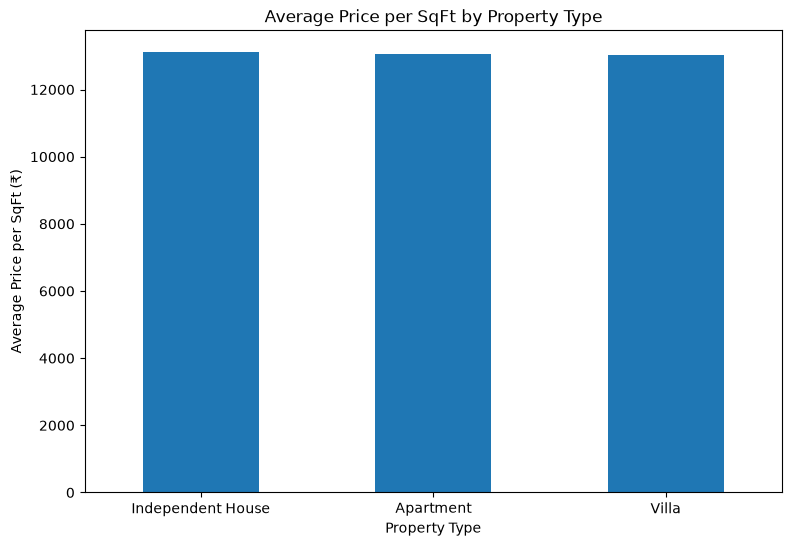

In [38]:
#3- Calculate average price per square foot for each property type

'''Compare the average price per square foot among:
Apartment
Independent House
Villa'''

price_by_type = (
    df.groupby("Property_Type")["Price_per_SqFt"]
    .mean()
    .sort_values(ascending=False)
)

# Display the values
print("Average Price per SqFt by Property Type")
print("----------------------------------------")
print(price_by_type)

# Create a bar chart
plt.figure(figsize=(9, 6))

price_by_type.plot(kind="bar")

# Add title and labels
plt.title("Average Price per SqFt by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Average Price per SqFt (₹)")

# Rotate x-axis labels for readability
plt.xticks(rotation=0)

# Display the graph
plt.show()

Correlation between Property Size and Price: -0.0025285467904830965


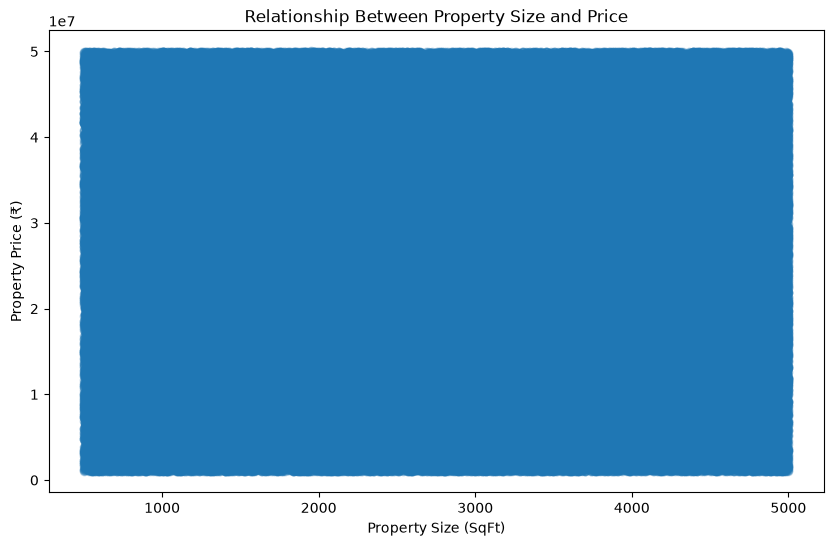

In [39]:
# 4- Relationship Between Property Size and Price.

'''Determine whether larger properties generally have higher prices.'''

# Calculate the correlation between property size and price
correlation = df["Size_in_SqFt"].corr(
    df["Price_in_Lakhs"]
)
# Display the correlation
print("Correlation between Property Size and Price:",
      correlation)
# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(
    df["Size_in_SqFt"],
    df["Price_in_Lakhs"],
    alpha=0.3
)

# Add title and labels
plt.title("Relationship Between Property Size and Price")
plt.xlabel("Property Size (SqFt)")
plt.ylabel("Property Price (₹)")

# Display the graph
plt.show()

In [40]:
# 5- Outliers in Price per SqFt and Property Size.
'''IQR method
We calculate:
Q1 = 25th percentile
Q3 = 75th percentile
IQR = Q3 − Q1

Then:
Lower limit = Q1 − 1.5 × IQR
Upper limit = Q3 + 1.5 × IQR

Values outside these limits are considered potential outliers.

'''
# Function to detect outliers using the IQR method
def find_outliers(column):

    # Calculate the first quartile
    Q1 = df[column].quantile(0.25)

    # Calculate the third quartile
    Q3 = df[column].quantile(0.75)

    # Calculate the interquartile range
    IQR = Q3 - Q1

    # Calculate the lower boundary
    lower_limit = Q1 - 1.5 * IQR

    # Calculate the upper boundary
    upper_limit = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    # Return the results
    return Q1, Q3, IQR, lower_limit, upper_limit, outliers


# Check outliers in Price_per_SqFt
price_results = find_outliers("Price_per_SqFt")

print("Price per SqFt Outlier Analysis")
print("--------------------------------")
print("Q1:", price_results[0])
print("Q3:", price_results[1])
print("IQR:", price_results[2])
print("Lower Limit:", price_results[3])
print("Upper Limit:", price_results[4])
print("Number of Outliers:", len(price_results[5]))


# Check outliers in Size_in_SqFt
size_results = find_outliers("Size_in_SqFt")

print("\nProperty Size Outlier Analysis")
print("------------------------------")
print("Q1:", size_results[0])
print("Q3:", size_results[1])
print("IQR:", size_results[2])
print("Lower Limit:", size_results[3])
print("Upper Limit:", size_results[4])
print("Number of Outliers:", len(size_results[5]))

Price per SqFt Outlier Analysis
--------------------------------
Q1: 4802.839710440703
Q3: 15987.388517279822
IQR: 11184.548806839119
Lower Limit: -11973.983499817974
Upper Limit: 32764.2117275385
Number of Outliers: 19723

Property Size Outlier Analysis
------------------------------
Q1: 1623.0
Q3: 3874.0
IQR: 2251.0
Lower Limit: -1753.5
Upper Limit: 7250.5
Number of Outliers: 0


visualization for box plot

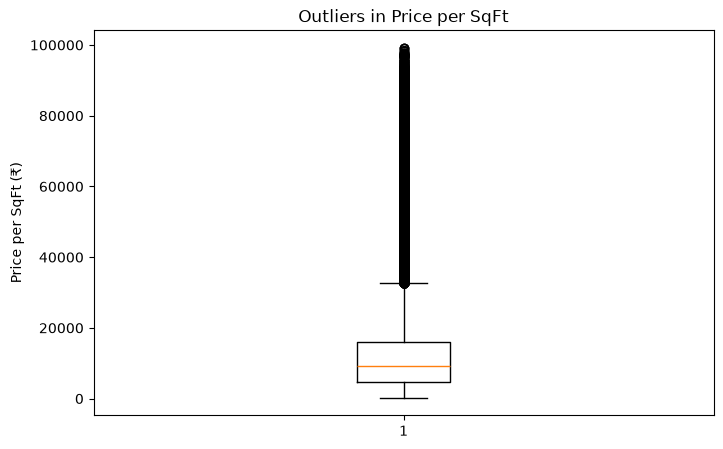

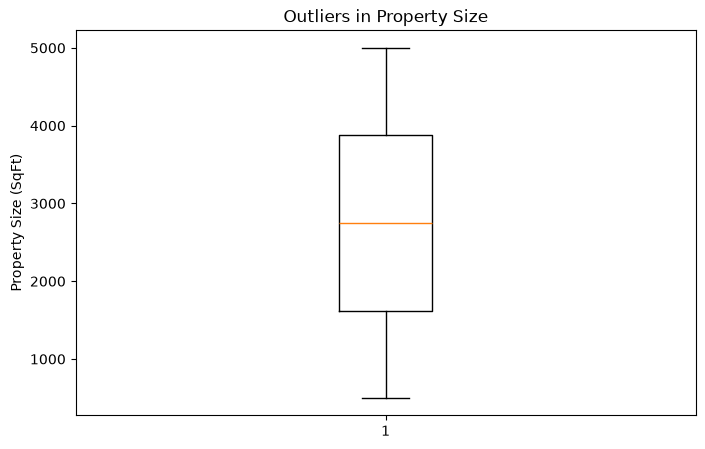

In [41]:
# Create a boxplot for Price per SqFt
plt.figure(figsize=(8, 5))

plt.boxplot(df["Price_per_SqFt"])

plt.title("Outliers in Price per SqFt")
plt.ylabel("Price per SqFt (₹)")

plt.show()


# Create a boxplot for Property Size
plt.figure(figsize=(8, 5))

plt.boxplot(df["Size_in_SqFt"])

plt.title("Outliers in Property Size")
plt.ylabel("Property Size (SqFt)")

plt.show()

Location-based Analysis


Average Price per SqFt by State
--------------------------------
State
Karnataka         13252.204890
Andhra Pradesh    13201.578837
Uttar Pradesh     13142.519647
Tamil Nadu        13132.420856
Telangana         13093.098881
Gujarat           13091.146097
Assam             13084.021567
Maharashtra       13070.133795
Madhya Pradesh    13069.029215
Haryana           13068.740809
West Bengal       13060.549020
Bihar             13050.620920
Odisha            13032.919018
Chhattisgarh      13027.129980
Uttarakhand       13027.094704
Kerala            12982.217227
Jharkhand         12975.461570
Delhi             12941.348867
Rajasthan         12932.174277
Punjab            12931.487587
Name: Price_per_SqFt, dtype: float64


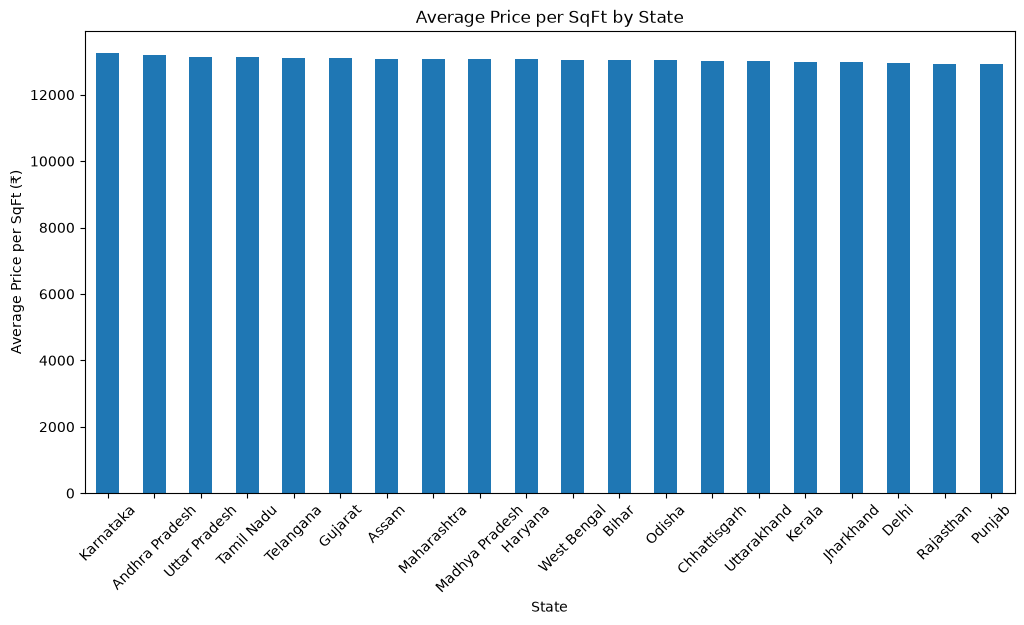

In [42]:
# 6 -Average Price per SqFt by State.

'''Find which states have the highest and lowest average property price per square foot.'''

# Calculate the average price per square foot for each state
state_price = (
    df.groupby("State")["Price_per_SqFt"]
    .mean()
    .sort_values(ascending=False)
)

# Display the result
print("Average Price per SqFt by State")
print("--------------------------------")
print(state_price)

#VISUALIZATION -------------------------------------

# Create a bar chart
plt.figure(figsize=(12, 6))

state_price.plot(kind="bar")

# Add title and labels
plt.title("Average Price per SqFt by State")
plt.xlabel("State")
plt.ylabel("Average Price per SqFt (₹)")

# Rotate state names for readability
plt.xticks(rotation=45)

# Display the chart
plt.show()

In [43]:
# 7 - Average Property Price by City

"""Compare the average property price across all cities."""

# Calculate the average property price for each city
city_price = (
    df.groupby("City")["Price_in_Lakhs"]
    .mean()
    .sort_values(ascending=False)
)

# Display the result
print("Average Property Price by City")
print("------------------------------")
print(city_price)


Average Property Price by City
------------------------------
City
Bangalore         2.584566e+07
Surat             2.580805e+07
Kochi             2.574152e+07
Gaya              2.570534e+07
Mangalore         2.569209e+07
Dehradun          2.568901e+07
Mysore            2.568482e+07
Chennai           2.568302e+07
Hyderabad         2.565941e+07
Coimbatore        2.565047e+07
Bhopal            2.564989e+07
Pune              2.564957e+07
Noida             2.562872e+07
Lucknow           2.562124e+07
Vishakhapatnam    2.557724e+07
Nagpur            2.555320e+07
Indore            2.554138e+07
Jaipur            2.552462e+07
Bhubaneswar       2.549022e+07
Faridabad         2.548624e+07
Vijayawada        2.546438e+07
Ranchi            2.546245e+07
Warangal          2.544751e+07
Durgapur          2.541002e+07
Gurgaon           2.540275e+07
Jodhpur           2.539479e+07
Kolkata           2.539149e+07
Ahmedabad         2.535868e+07
Raipur            2.534824e+07
Dwarka            2.534543e+07
Lud

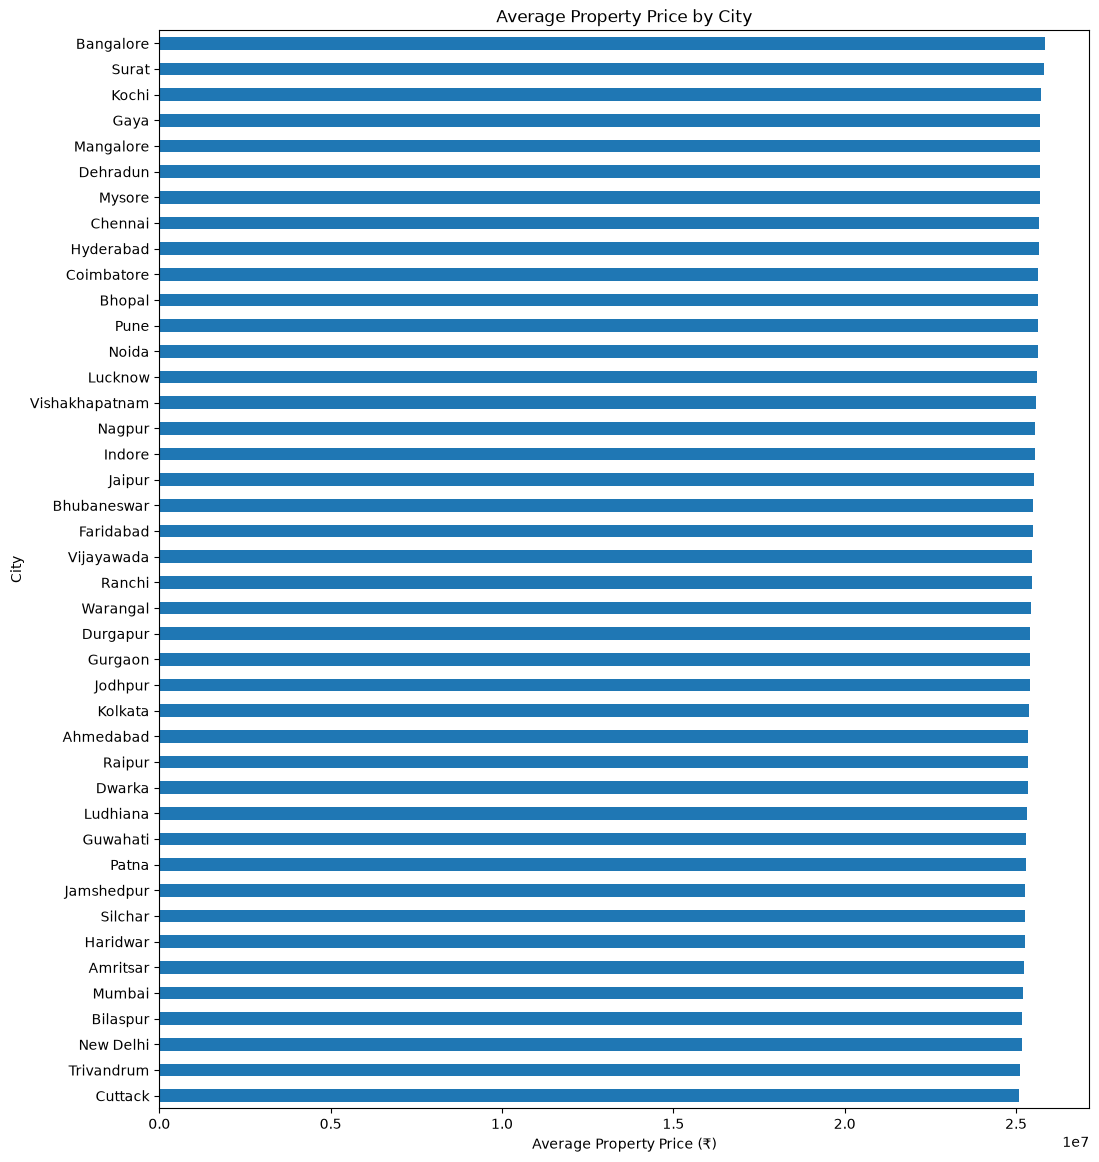

In [44]:
# Visualization----------------------------------------
# there are 42 cities

# Create a horizontal bar chart
plt.figure(figsize=(12, 14))

city_price.sort_values().plot(kind="barh")

# Add title and labels
plt.title("Average Property Price by City")
plt.xlabel("Average Property Price (₹)")
plt.ylabel("City")

# Display the chart
plt.show()

In [45]:
# 8 - Median Age of Properties by Locality

'''Finding the typical property age in each locality.
We use the median, rather than the mean, because property ages can vary and the median is less affected by extreme values.'''

# Calculate the median property age for each locality
locality_age = (
    df.groupby("Locality")["Age_of_Property"]
    .median()
    .sort_values(ascending=False)
)

# Display the result
print("Median Property Age by Locality")
print("--------------------------------")
print(locality_age)

'''There are 500 localities, so plotting all 500 at once would be difficult to read. Instead,
we can examine the oldest and youngest localities.'''

#Top 10 oldest localities
# Select the 10 localities with the highest median property age
oldest_localities = locality_age.head(10)

# Display the result
print("Top 10 Oldest Localities")
print("------------------------")
print(oldest_localities)


Median Property Age by Locality
--------------------------------
Locality
Locality_72     21.0
Locality_403    21.0
Locality_75     20.0
Locality_127    20.0
Locality_1      20.0
                ... 
Locality_56     17.0
Locality_13     17.0
Locality_63     17.0
Locality_10     17.0
Locality_443    16.0
Name: Age_of_Property, Length: 500, dtype: float64
Top 10 Oldest Localities
------------------------
Locality
Locality_72     21.0
Locality_403    21.0
Locality_75     20.0
Locality_127    20.0
Locality_1      20.0
Locality_99     20.0
Locality_499    20.0
Locality_51     20.0
Locality_491    20.0
Locality_474    20.0
Name: Age_of_Property, dtype: float64


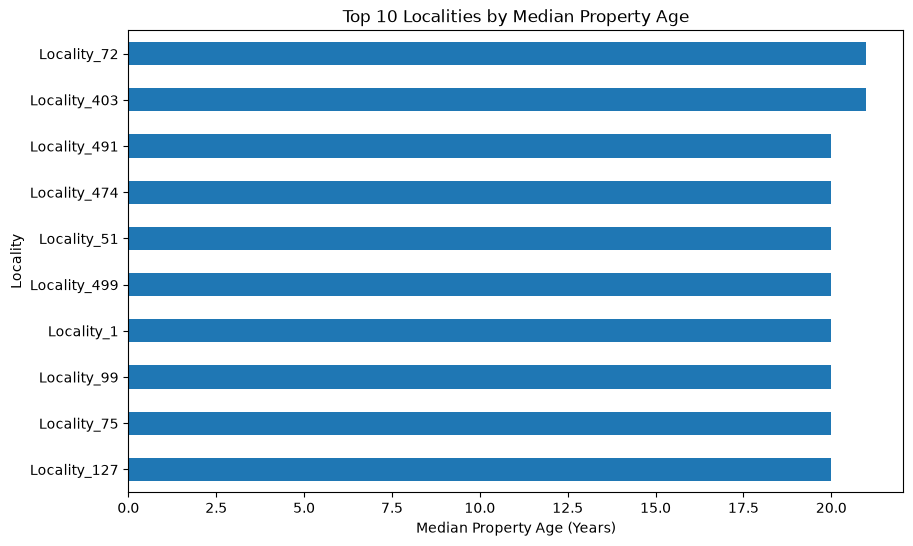

In [46]:
'''Visualization'''

# Create a bar chart for the 10 oldest localities
plt.figure(figsize=(10, 6))

oldest_localities.sort_values().plot(kind="barh")

# Add title and labels
plt.title("Top 10 Localities by Median Property Age")
plt.xlabel("Median Property Age (Years)")
plt.ylabel("Locality")

# Display the chart
plt.show()

In [47]:
# 9 - BHK Distribution Across Cities
'''Understand how the number of bedrooms (BHK) is distributed across different cities.
Here, a count table/heatmap is useful because we're comparing two categorical variables: City and BHK.
First, create the distribution table'''

# Create a cross-tabulation of City and BHK
bhk_city = pd.crosstab(
    df["City"],
    df["BHK"]
)

# Display the table
print("BHK Distribution Across Cities")
print("------------------------------")
print(bhk_city)

BHK Distribution Across Cities
------------------------------
BHK                1     2     3     4     5
City                                        
Ahmedabad       1264  1267  1272  1258  1350
Amritsar        1284  1239  1234  1224  1240
Bangalore        839   823   802   833   847
Bhopal          1238  1235  1255  1259  1297
Bhubaneswar     1236  1293  1299  1217  1278
Bilaspur        1210  1252  1275  1268  1258
Chennai         1263  1232  1183  1257  1233
Coimbatore      1236  1301  1317  1345  1262
Cuttack         1320  1292  1301  1236  1209
Dehradun        1238  1297  1225  1248  1226
Durgapur        1311  1259  1287  1260  1270
Dwarka          1295  1211  1248  1216  1276
Faridabad       1202  1231  1261  1214  1261
Gaya            1356  1259  1146  1179  1230
Gurgaon         1241  1221  1239  1232  1212
Guwahati        1240  1158  1272  1188  1234
Haridwar        1233  1290  1230  1223  1291
Hyderabad       1190  1312  1256  1271  1244
Indore          1264  1213  1218  1245

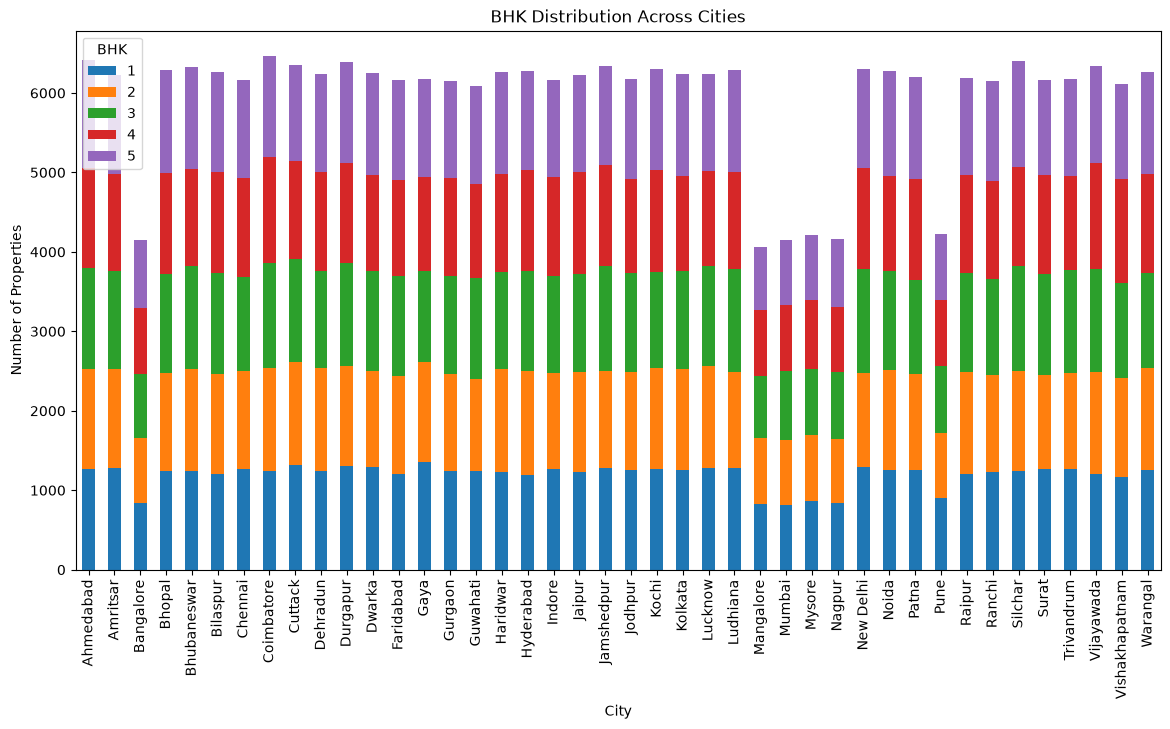

In [48]:
#Visualization
# Create a stacked bar chart
bhk_city.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

# Add title and labels
plt.title("BHK Distribution Across Cities")
plt.xlabel("City")
plt.ylabel("Number of Properties")

# Rotate city names
plt.xticks(rotation=90)

# Display the chart
plt.show()

In [49]:
# 10 - Price Trends for the Top 5 Most Expensive Localities

'''There is an important issue here.
dataset has:
Locality
Price_in_Lakhs
Year_Built

But it does not have a property listing/sale date or transaction year.
Therefore, we cannot honestly calculate a true price trend over time such as:
2020 → ₹X
2021 → ₹Y
2022 → ₹Z
using Year_Built, because Year_Built represents when the property was constructed, not when it was sold/listed.

What we can correctly do
First identify the top 5 most expensive localities based on average property price.'''

# Calculate average property price for each locality
locality_price = (
    df.groupby("Locality")["Price_in_Lakhs"]
    .mean()
    .sort_values(ascending=False)
)

# Select the top 5 most expensive localities
top_5_localities = locality_price.head(5)

# Display the top 5
print("Top 5 Most Expensive Localities")
print("--------------------------------")
print(top_5_localities)

Top 5 Most Expensive Localities
--------------------------------
Locality
Locality_395    2.754260e+07
Locality_366    2.734120e+07
Locality_497    2.699955e+07
Locality_360    2.698068e+07
Locality_203    2.690337e+07
Name: Price_in_Lakhs, dtype: float64


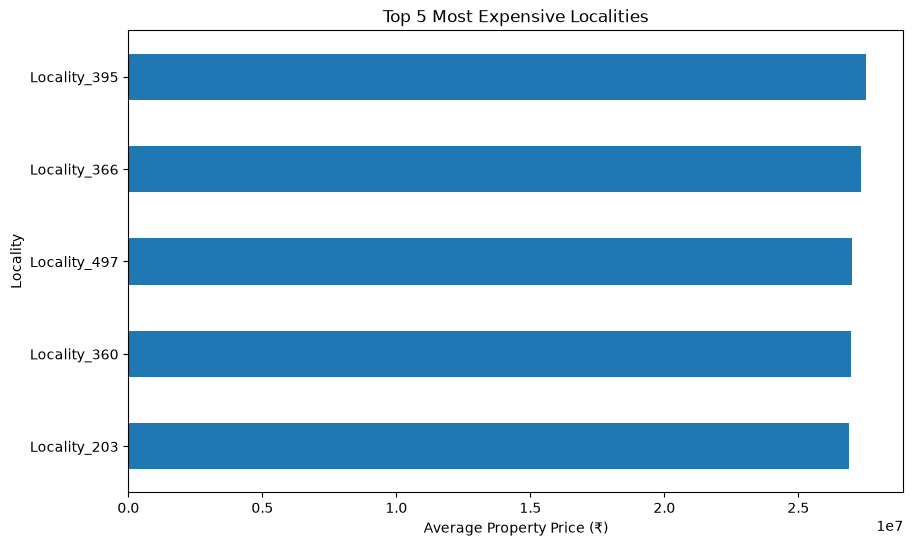

In [50]:
'''visualization'''
# Create a bar chart for the top 5 most expensive localities
plt.figure(figsize=(10, 6))

top_5_localities.sort_values().plot(kind="barh")

# Add title and labels
plt.title("Top 5 Most Expensive Localities")
plt.xlabel("Average Property Price (₹)")
plt.ylabel("Locality")

# Display the chart
plt.show()

11–15: Feature Relationship & Correlation


In [51]:
# 11 -How are numeric features correlated with each other?

# Select all numerical columns
numeric_df = df.select_dtypes(include=["int64", "int32", "float64"])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                                             ID       BHK  Size_in_SqFt  \
ID                                     1.000000 -0.001718     -0.002293   
BHK                                   -0.001718  1.000000     -0.001033   
Size_in_SqFt                          -0.002293 -0.001033      1.000000   
Price_in_Lakhs                        -0.001636 -0.000980     -0.002529   
Price_per_SqFt                        -0.001328  0.001138     -0.614610   
Year_Built                             0.002734  0.000917      0.004135   
Floor_No                              -0.000214  0.001263     -0.002775   
Total_Floors                           0.002044 -0.000620     -0.003641   
Age_of_Property                       -0.002734 -0.000917     -0.004135   
Nearby_Schools                        -0.001203 -0.000762      0.001966   
Nearby_Hospitals                       0.001429  0.001162     -0.001695   
Parking_Space                         -0.002999 -0.002339      0.000875   
Secur

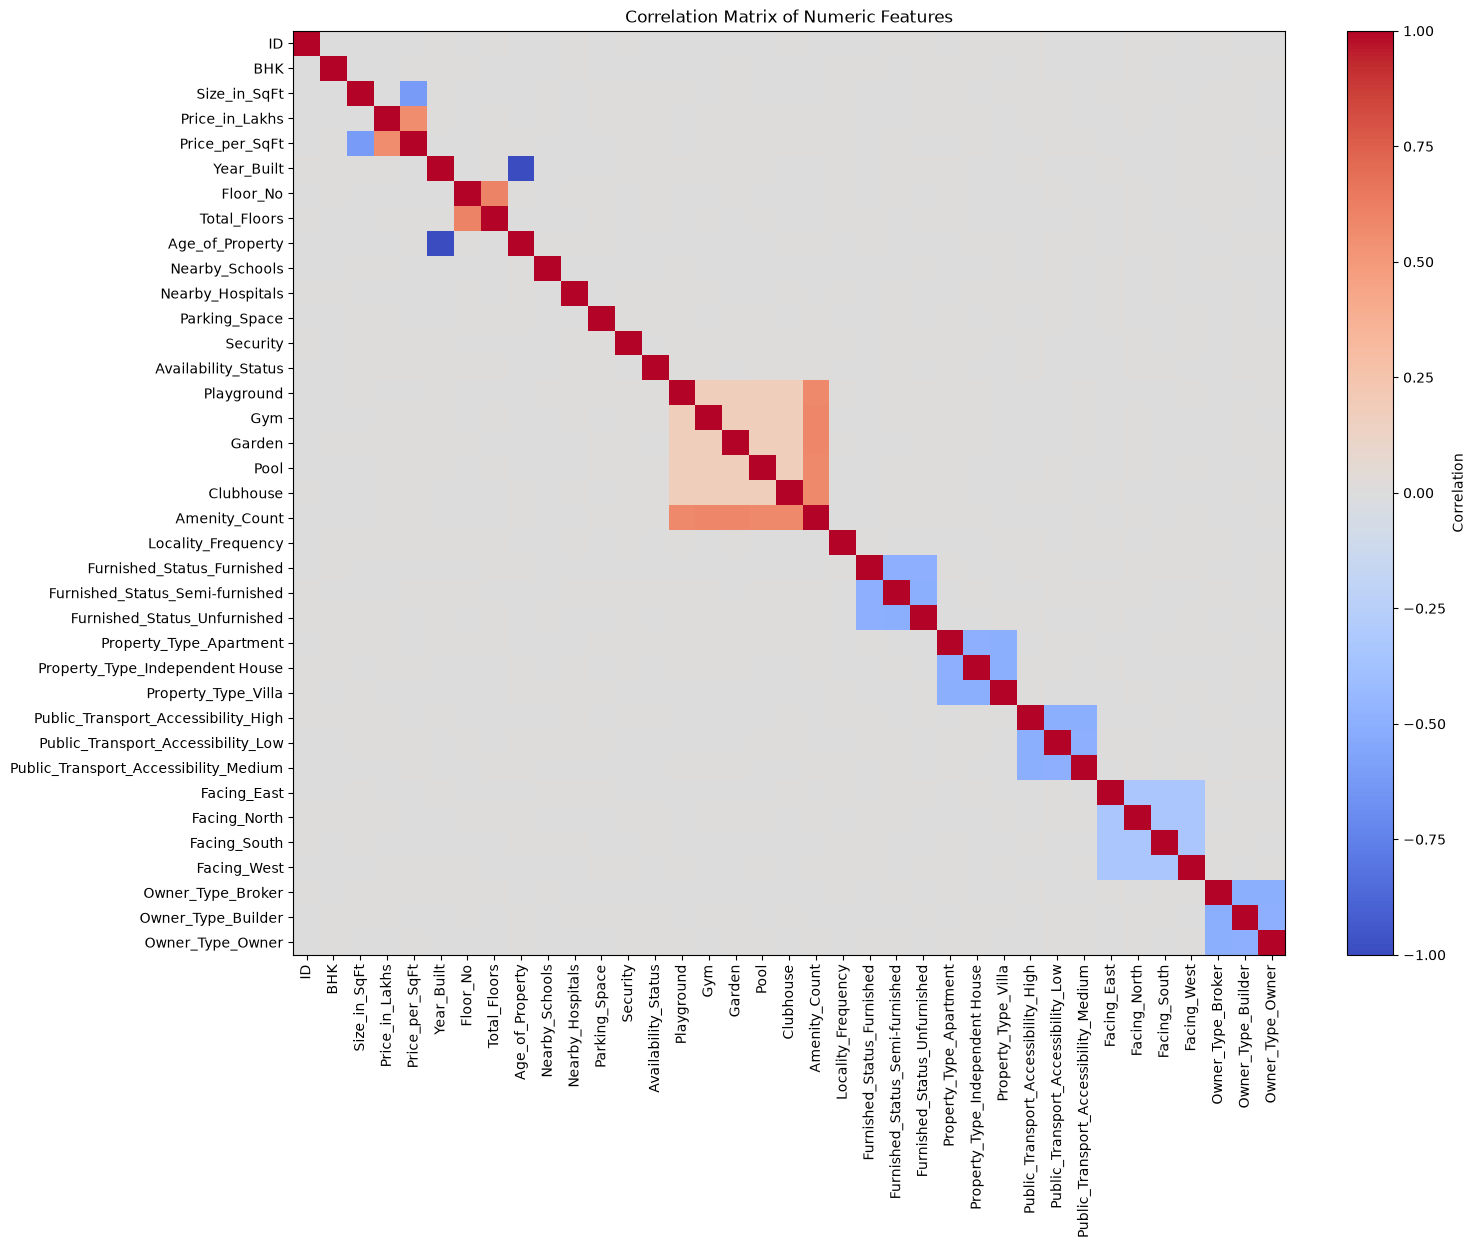

In [52]:
# HEATMAP - 
import matplotlib.pyplot as plt

# Create the figure
plt.figure(figsize=(16, 12))

# Display the correlation matrix as an image
plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    aspect="auto"
)

# Add color bar
plt.colorbar(label="Correlation")

# Add column names to x-axis
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

# Add column names to y-axis
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

# Add title
plt.title("Correlation Matrix of Numeric Features")

# Display the chart
plt.show()

Correlation between Nearby Schools and Price per SqFt: -5.8234385899462665e-05


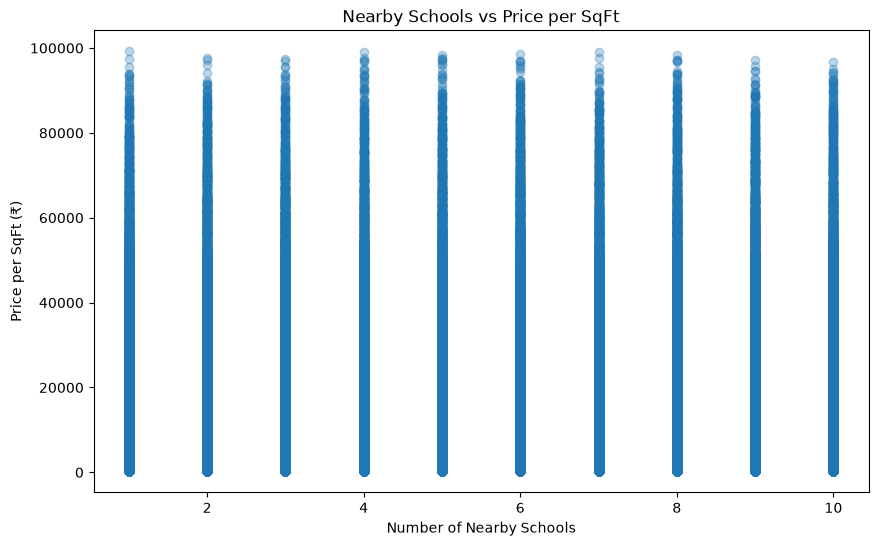

In [53]:
# 12. How do nearby schools relate to price per sq ft?
# Calculate the correlation
school_correlation = df["Nearby_Schools"].corr(
    df["Price_per_SqFt"]
)

# Display the correlation
print(
    "Correlation between Nearby Schools and Price per SqFt:",
    school_correlation
)

# Create a scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Nearby_Schools"],
    df["Price_per_SqFt"],
    alpha=0.3
)

# Add title and labels
plt.title("Nearby Schools vs Price per SqFt")
plt.xlabel("Number of Nearby Schools")
plt.ylabel("Price per SqFt (₹)")

# Display the graph
plt.show()

Correlation between Nearby Hospitals and Price per SqFt: -0.00012211709317290367


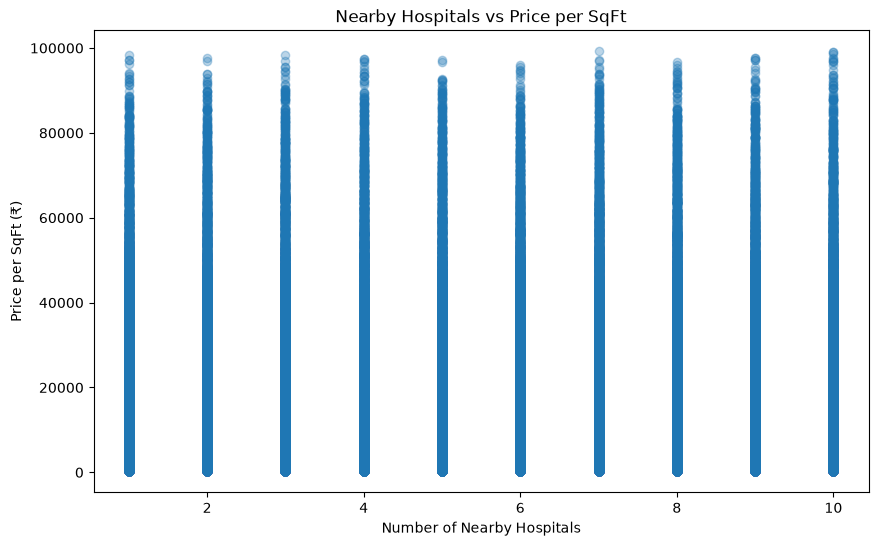

In [54]:
# 13. How do nearby hospitals relate to price per sq ft?
# Calculate the correlation
hospital_correlation = df["Nearby_Hospitals"].corr(
    df["Price_per_SqFt"]
)

# Display the correlation
print(
    "Correlation between Nearby Hospitals and Price per SqFt:",
    hospital_correlation
)

# Create a scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Nearby_Hospitals"],
    df["Price_per_SqFt"],
    alpha=0.3
)

# Add title and labels
plt.title("Nearby Hospitals vs Price per SqFt")
plt.xlabel("Number of Nearby Hospitals")
plt.ylabel("Price per SqFt (₹)")

# Display the graph
plt.show()

Average Property Price by Furnished Status
-------------------------------------------
Furnished_Status
Unfurnished       2.549798e+07
Furnished         2.544455e+07
Semi-furnished    2.543348e+07
Name: Price_in_Lakhs, dtype: float64


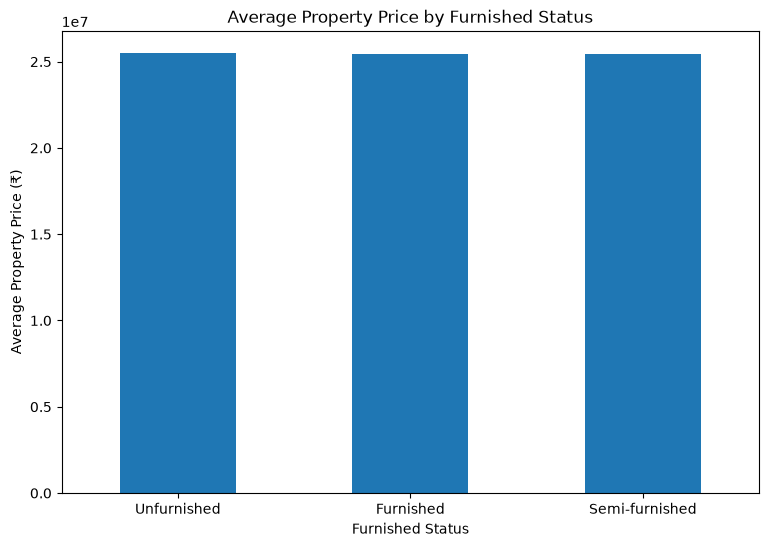

In [55]:
# 14. How does price vary by furnished status?

# Calculate average property price for each furnished status
furnished_price = (
    df.groupby("Furnished_Status")["Price_in_Lakhs"]
    .mean()
    .sort_values(ascending=False)
)

# Display the results
print("Average Property Price by Furnished Status")
print("-------------------------------------------")
print(furnished_price)

'''VISUALIZATION'''

# Create a bar chart
plt.figure(figsize=(9, 6))

furnished_price.plot(kind="bar")

# Add title and labels
plt.title("Average Property Price by Furnished Status")
plt.xlabel("Furnished Status")
plt.ylabel("Average Property Price (₹)")

# Keep category labels horizontal
plt.xticks(rotation=0)

# Display the graph
plt.show()

Average Price per SqFt by Facing Direction
------------------------------------------
Facing
West     13140.023043
South    13044.110380
North    13024.865037
East     13023.700899
Name: Price_per_SqFt, dtype: float64


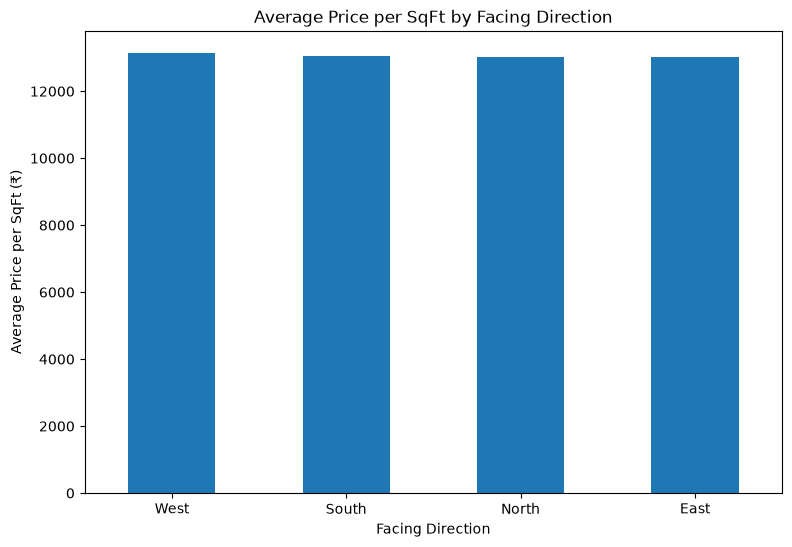

In [56]:
# 15. How does price per sq ft vary by property facing direction?

# Calculate average price per sq ft for each facing direction
facing_price = (
    df.groupby("Facing")["Price_per_SqFt"]
    .mean()
    .sort_values(ascending=False)
)

# Display the results
print("Average Price per SqFt by Facing Direction")
print("------------------------------------------")
print(facing_price)

'''VISUALIZATION'''

# Create a bar chart
plt.figure(figsize=(9, 6))

facing_price.plot(kind="bar")

# Add title and labels
plt.title("Average Price per SqFt by Facing Direction")
plt.xlabel("Facing Direction")
plt.ylabel("Average Price per SqFt (₹)")

# Keep direction labels horizontal
plt.xticks(rotation=0)

# Display the graph
plt.show()

Number of Properties by Owner Type
----------------------------------
Owner_Type
Broker     83479
Owner      83268
Builder    83253
Name: count, dtype: int64


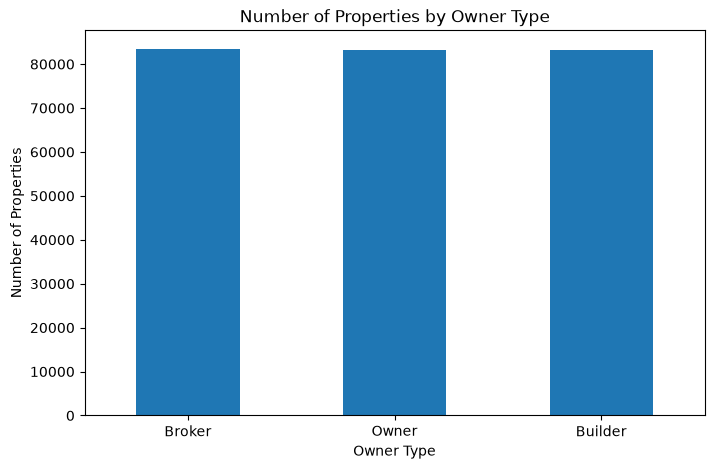

In [57]:
# 16. How many properties belong to each owner type?

# Count the number of properties for each owner type
owner_counts = df["Owner_Type"].value_counts()

# Display the result
print("Number of Properties by Owner Type")
print("----------------------------------")
print(owner_counts)

'''VISUALIZATION'''

# Create a bar chart to visualize the property count
plt.figure(figsize=(8, 5))

owner_counts.plot(kind="bar")

# Add chart title and labels
plt.title("Number of Properties by Owner Type")
plt.xlabel("Owner Type")
plt.ylabel("Number of Properties")

# Keep the owner type labels horizontal
plt.xticks(rotation=0)

# Display the chart
plt.show()

Number of Properties by Availability Status
--------------------------------------------
Availability_Status
Under_Construction    125035
Ready_to_Move         124965
Name: count, dtype: int64


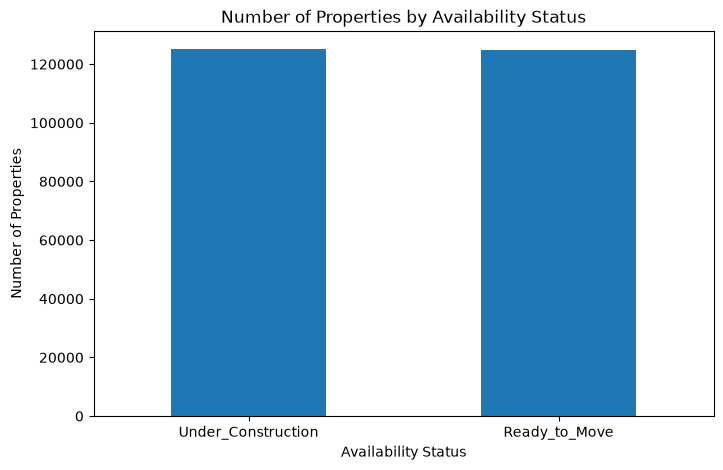

In [58]:
# 17. How many properties are available under each availability status?

'''Your column has already been encoded as:
1 → Ready_to_Move
0 → Under_Construction
For easier interpretation, we'll use the original meaning of the values.'''

# Replace the encoded values with their original status names
availability_labels = df["Availability_Status"].map({
    1: "Ready_to_Move",
    0: "Under_Construction"
})

# Count properties for each status
availability_counts = availability_labels.value_counts()

# Display the result
print("Number of Properties by Availability Status")
print("--------------------------------------------")
print(availability_counts)

#VISUALIZATION.

# Create a bar chart
plt.figure(figsize=(8, 5))

availability_counts.plot(kind="bar")

# Add title and axis labels
plt.title("Number of Properties by Availability Status")
plt.xlabel("Availability Status")
plt.ylabel("Number of Properties")

# Keep labels horizontal
plt.xticks(rotation=0)

# Display the chart
plt.show()

Average Property Price by Parking Availability
-----------------------------------------------
Parking_Space
No Parking           2.544294e+07
Parking Available    2.547455e+07
Name: Price_in_Lakhs, dtype: float64


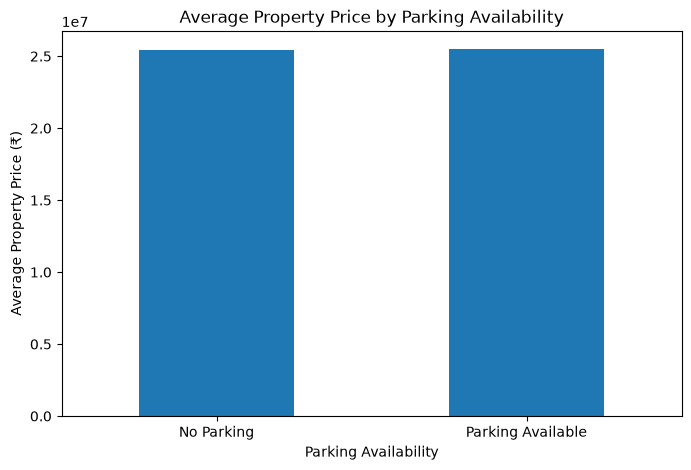

In [59]:
# 18. Does parking space affect property price?

'''Since Parking_Space is already encoded:
1 → Yes
0 → No'''

# Calculate the average property price for each parking category
parking_price = (
    df.groupby("Parking_Space")["Price_in_Lakhs"]
    .mean()
)

# Rename the index values for easier understanding
parking_price.index = parking_price.index.map({
    1: "Parking Available",
    0: "No Parking"
})

# Display the result
print("Average Property Price by Parking Availability")
print("-----------------------------------------------")
print(parking_price)

#VISUALIZATION.

# Create a bar chart
plt.figure(figsize=(8, 5))

parking_price.plot(kind="bar")

# Add title and axis labels
plt.title("Average Property Price by Parking Availability")
plt.xlabel("Parking Availability")
plt.ylabel("Average Property Price (₹)")

# Keep labels horizontal
plt.xticks(rotation=0)

# Display the chart
plt.show()


Average Price per SqFt Based on Amenities
-----------------------------------------
              No_Amenity  Amenity_Available
Playground  13072.353020       13048.866456
Gym         12999.496216       13097.498239
Garden      13048.733160       13064.628719
Pool        13036.638728       13072.687360
Clubhouse   13041.214374       13069.648816


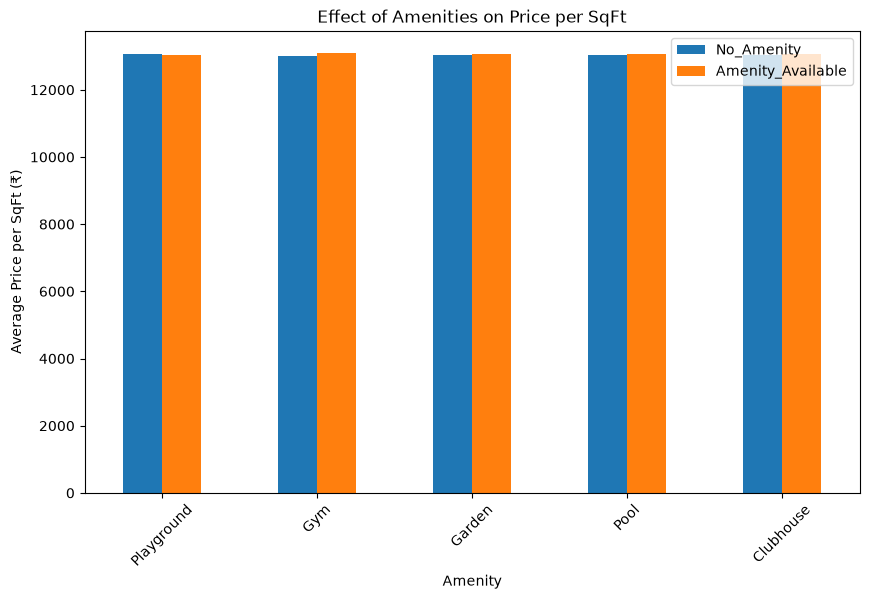

In [60]:
# 19. How do amenities affect price per sq ft?

'''Since we already converted the five amenities into separate 0/1 columns, we can compare the average Price_per_SqFt for properties with and without each amenity.
The five amenities are:

Playground
Gym
Garden
Pool
Clubhouse'''

# List of the individual amenity columns
amenity_columns = [
    "Playground",
    "Gym",
    "Garden",
    "Pool",
    "Clubhouse"
]

# Create an empty dictionary to store the average price per sq ft
amenity_price = {}

# Calculate the average price per sq ft for each amenity
for amenity in amenity_columns:

    # Group properties based on whether the amenity is available
    # 1 = Available, 0 = Not Available
    average_price = df.groupby(amenity)["Price_per_SqFt"].mean()

    # Store the result
    amenity_price[amenity] = average_price

# Convert the results into a DataFrame
amenity_price_df = pd.DataFrame(amenity_price).T

# Rename the columns for easier understanding
amenity_price_df.columns = [
    "No_Amenity",
    "Amenity_Available"
]

# Display the result
print("Average Price per SqFt Based on Amenities")
print("-----------------------------------------")
print(amenity_price_df)

#visualization 

# Create a bar chart
amenity_price_df.plot(
    kind="bar",
    figsize=(10, 6)
)

# Add title and labels
plt.title("Effect of Amenities on Price per SqFt")
plt.xlabel("Amenity")
plt.ylabel("Average Price per SqFt (₹)")

# Rotate the amenity names slightly
plt.xticks(rotation=45)

# Display the chart
plt.show()

Average Price per SqFt by Public Transport Accessibility
--------------------------------------------------------
Public_Transport_Accessibility
Low       13085.539036
Medium    13062.233088
High      13027.242143
Name: Price_per_SqFt, dtype: float64


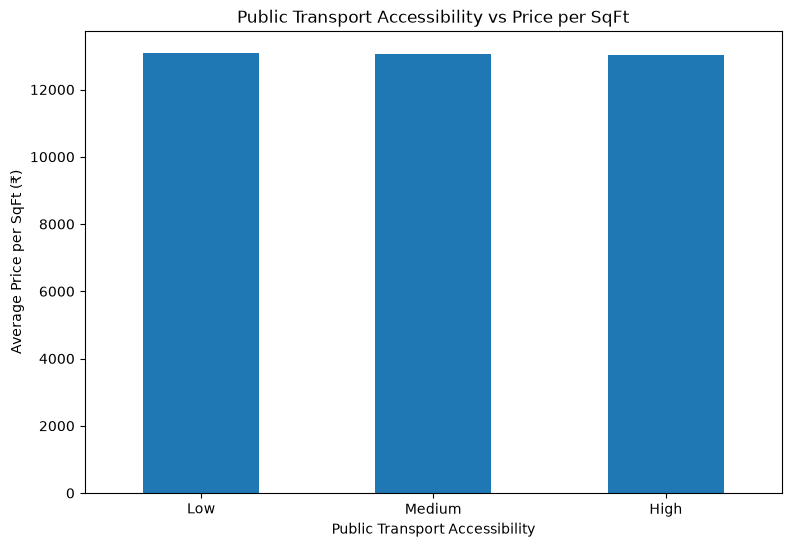

In [61]:
# 20. How does public transport accessibility relate to price per sq ft or investment potential?

'''For this question, we ll first examine the relationship between public transport accessibility and average price per sq ft.
Your column contains:

High
Medium
Low'''

# Calculate the average price per sq ft
# for each public transport accessibility level
transport_price = (
    df.groupby("Public_Transport_Accessibility")["Price_per_SqFt"]
    .mean()
    .sort_values(ascending=False)
)

# Display the result
print("Average Price per SqFt by Public Transport Accessibility")
print("--------------------------------------------------------")
print(transport_price)

#VISUALIZATION.

# Create a bar chart
plt.figure(figsize=(9, 6))

transport_price.plot(kind="bar")

# Add title and axis labels
plt.title("Public Transport Accessibility vs Price per SqFt")
plt.xlabel("Public Transport Accessibility")
plt.ylabel("Average Price per SqFt (₹)")

# Keep category labels horizontal
plt.xticks(rotation=0)

# Display the chart
plt.show()

#  Step 3: Model Development


CREATEING GOOD_INVESTMENT TARGET

In [62]:
# STEP 3.1: CREATE GOOD_INVESTMENT TARGET

# Calculate the median property price.
median_price = df["Price_in_Lakhs"].median()

# Calculate the median price per square foot.
median_price_sqft = df["Price_per_SqFt"].median()

# CONDITION 1: PRICE <= MEDIAN PRICE

# Give 1 point when the property's price is
# less than or equal to the median property price.
price_condition = (
    df["Price_in_Lakhs"] <= median_price
).astype(int)


# CONDITION 2: PRICE PER SQ FT <= MEDIAN PRICE PER SQ FT

# Give 1 point when the property's price per square foot
# is less than or equal to the median price per square foot.
price_sqft_condition = (
    df["Price_per_SqFt"] <= median_price_sqft
).astype(int)

# MULTI-FACTOR CONDITIONS

# BHK >= 3
bhk_condition = (
    df["BHK"] >= 3
).astype(int)

# Ready-to-Move property
ready_condition = (
    df["Availability_Status"] == 1
).astype(int)

# High public transport accessibility
transport_condition = (
    df["Public_Transport_Accessibility"] == "High"
).astype(int)

# Calculate the number of amenities.
amenity_condition = (
    df["Amenity_Count"] >= df["Amenity_Count"].median()
).astype(int)


# ---------------------------------------------------------
# CREATE MULTI-FACTOR INVESTMENT SCORE
# ---------------------------------------------------------

df["Investment_Score"] = (
    price_condition
    + price_sqft_condition
    + bhk_condition
    + ready_condition
    + transport_condition
    + amenity_condition
)


# ---------------------------------------------------------
# CREATE GOOD_INVESTMENT
# ---------------------------------------------------------

# A score of 4 or more means the property
# satisfies enough investment conditions.
df["Good_Investment"] = (
    df["Investment_Score"] >= 4
).astype(int)


# ---------------------------------------------------------
# DISPLAY RESULTS
# ---------------------------------------------------------

print("Median Property Price:", median_price)
print("Median Price per SqFt:", median_price_sqft)

print("\nInvestment Score Distribution:")
print(df["Investment_Score"].value_counts().sort_index())

print("\nGood Investment Distribution:")
print(df["Good_Investment"].value_counts())

print("\nFirst 10 rows:")
print(
    df[
        [
            "Price_in_Lakhs",
            "Price_per_SqFt",
            "BHK",
            "Availability_Status",
            "Public_Transport_Accessibility",
            "Amenity_Count",
            "Investment_Score",
            "Good_Investment"
        ]
    ].head(10)
)

Median Property Price: 25387000.0
Median Price per SqFt: 9244.747593959637

Investment Score Distribution:
Investment_Score
0     5327
1    26272
2    56025
3    69780
4    57754
5    28982
6     5860
Name: count, dtype: int64

Good Investment Distribution:
Good_Investment
0    157404
1     92596
Name: count, dtype: int64

First 10 rows:
   Price_in_Lakhs  Price_per_SqFt  BHK  Availability_Status  \
0        48976000    10332.489451    1                    1   
1        19552000     8270.727580    3                    0   
2        18379000     5046.403075    2                    1   
3        30029000    10955.490697    2                    1   
4        18290000     3792.245490    4                    1   
5        13528000     3865.142857    4                    1   
6        31812000     6591.794447    3                    0   
7        14138999     3325.258467    5                    0   
8        18916000     7063.480209    4                    0   
9        18742000    13454.414

In [63]:
# ---------------------------------------------------------
# STEP 3.2: PREPARE X AND y
# ---------------------------------------------------------

# Create the target variable.
# y contains the value that the classification models will learn to predict.

y = df["Good_Investment"]

# Columns that should NOT be used as ML features.
# ID is only an identifier.
# Investment_Score directly created the target, so including
# it would cause target leakage.
# Good_Investment itself is the target.
# Original categorical columns are excluded because we have
# already created their numerical one-hot encoded versions.
columns_to_drop = [
    "ID",
    "Good_Investment",
    "Investment_Score",
    "State",
    "City",
    "Locality",
    "Property_Type",
    "Furnished_Status",
    "Public_Transport_Accessibility",
    "Amenities",
    "Facing",
    "Owner_Type"
]

# Create X by removing the unwanted columns.
X = df.drop(columns=columns_to_drop)

# Display the shape of X and y.
print("X shape:", X.shape)
print("y shape:", y.shape)

# Display the feature columns.
print("\nFeatures used for classification:")
print(X.columns.tolist())

# Display target distribution.
print("\nTarget distribution:")
print(y.value_counts())

# Display target percentages.
print("\nTarget percentage:")
print(
    (y.value_counts(normalize=True) * 100).round(2)
)

X shape: (250000, 36)
y shape: (250000,)

Features used for classification:
['BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Parking_Space', 'Security', 'Availability_Status', 'Playground', 'Gym', 'Garden', 'Pool', 'Clubhouse', 'Amenity_Count', 'Locality_Frequency', 'Furnished_Status_Furnished', 'Furnished_Status_Semi-furnished', 'Furnished_Status_Unfurnished', 'Property_Type_Apartment', 'Property_Type_Independent House', 'Property_Type_Villa', 'Public_Transport_Accessibility_High', 'Public_Transport_Accessibility_Low', 'Public_Transport_Accessibility_Medium', 'Facing_East', 'Facing_North', 'Facing_South', 'Facing_West', 'Owner_Type_Broker', 'Owner_Type_Builder', 'Owner_Type_Owner']

Target distribution:
Good_Investment
0    157404
1     92596
Name: count, dtype: int64

Target percentage:
Good_Investment
0    62.96
1    37.04
Name: proportion, dtype: float64


In [64]:
# ---------------------------------------------------------
# STEP 3.3: TRAIN-TEST SPLIT
# ---------------------------------------------------------

# Import the train_test_split function from scikit-learn.
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets.
# test_size=0.20 means 20% of the data will be used for testing.
# random_state=42 ensures that we get the same split every time.
# stratify=y keeps the Good_Investment class distribution
# approximately the same in both training and testing data.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shapes of the resulting datasets.
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Check the class distribution in the training data.
print("\nTraining target distribution:")
print(y_train.value_counts())

# Check the class distribution in the testing data.
print("\nTesting target distribution:")
print(y_test.value_counts())

# Check the percentages in the training data.
print("\nTraining target percentage:")
print((y_train.value_counts(normalize=True) * 100).round(2))

# Check the percentages in the testing data.
print("\nTesting target percentage:")
print((y_test.value_counts(normalize=True) * 100).round(2))

X_train shape: (200000, 36)
X_test shape: (50000, 36)
y_train shape: (200000,)
y_test shape: (50000,)

Training target distribution:
Good_Investment
0    125923
1     74077
Name: count, dtype: int64

Testing target distribution:
Good_Investment
0    31481
1    18519
Name: count, dtype: int64

Training target percentage:
Good_Investment
0    62.96
1    37.04
Name: proportion, dtype: float64

Testing target percentage:
Good_Investment
0    62.96
1    37.04
Name: proportion, dtype: float64


In [65]:
# ---------------------------------------------------------
# STEP 3.4: FEATURE SCALING
# ---------------------------------------------------------

# Import StandardScaler from scikit-learn.
from sklearn.preprocessing import StandardScaler

# Create the scaler object.
scaler = StandardScaler()

# Fit the scaler ONLY on the training data.
# The scaler learns the mean and standard deviation
# from X_train.
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data.
# We do NOT fit the scaler again on X_test.
X_test_scaled = scaler.transform(X_test)

# Display the shapes after scaling.
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

# Display a few scaled values from the training data.
print("\nFirst 5 rows of scaled training data:")
print(X_train_scaled[:5])

X_train_scaled shape: (200000, 36)
X_test_scaled shape: (50000, 36)

First 5 rows of scaled training data:
[[ 1.41545570e+00 -1.68811814e+00  1.44413113e+00  5.35234014e+00
   6.60731983e-01 -2.20129577e-01 -8.80216734e-01 -6.60731983e-01
   5.21363297e-01  8.71164600e-01 -9.97283689e-01 -1.00020002e+00
  -1.00048012e+00  8.18650096e-01  8.16420037e-01 -1.22738972e+00
  -1.22502559e+00  8.16683708e-01  1.30772425e-04 -4.59727313e-02
  -7.06337942e-01 -7.06902614e-01  1.41226948e+00 -7.04406459e-01
  -7.06703769e-01  1.40802601e+00 -7.08597534e-01 -7.08303014e-01
   1.41960289e+00  1.73626415e+00 -5.77196309e-01 -5.75702893e-01
  -5.80552663e-01 -7.07562914e-01  1.41734829e+00 -7.08215461e-01]
 [ 1.31515071e-03  1.13599924e+00 -1.24849929e+00 -8.57729373e-01
  -9.69031235e-01  4.50980131e-01  1.06898741e+00  9.69031235e-01
  -5.21481487e-01 -5.21295161e-01  1.00272371e+00  9.99800020e-01
   9.99520115e-01 -1.22152310e+00 -1.22485970e+00  8.14737146e-01
  -1.22502559e+00 -1.22446425e+00 

## ML FLOW 

In [66]:
# ===========================================================
# STEP 4 (MLflow): SETUP
# ===========================================================
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# Use a local SQLite file as the tracking store.
# (Remove/skip the placeholder "http://<server-ip>:5000" line
# from your old cell 110 — that pointed nowhere and would hang.)
mlflow.set_tracking_uri("sqlite:///mlflow.db")

# One experiment for the whole project. We tag each run with
# task type (classification/regression) instead of splitting
# into two experiments, so everything's browsable in one place.
mlflow.set_experiment("Real_Estate_Investment_Advisor")


# ===========================================================
# HELPER: log a classification run
# ===========================================================
def log_classification_run(run_name, model, accuracy, precision, recall, f1, roc_auc):
    with mlflow.start_run(run_name=run_name) as run:
        mlflow.set_tag("task", "classification")
        mlflow.set_tag("target", "Good_Investment")

        mlflow.log_params(model.get_params())

        mlflow.log_metrics({
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "roc_auc": roc_auc
        })

        # XGBoost has its own flavor; everything else uses sklearn's
        if "XGB" in type(model).__name__:
            mlflow.xgboost.log_model(model, name = "model")
        else:
            mlflow.sklearn.log_model(model, name = "model")

        print(f"Logged run: {run_name} (run_id={run.info.run_id})")
        return run.info.run_id


# ===========================================================
# HELPER: log a regression run
# ===========================================================
def log_regression_run(run_name, model, mae, rmse, r2):
    with mlflow.start_run(run_name=run_name) as run:
        mlflow.set_tag("task", "regression")
        mlflow.set_tag("target", "Future_Price_5Y")

        mlflow.log_params(model.get_params())

        mlflow.log_metrics({
            "mae": mae,
            "rmse": rmse,
            "r2": r2
        })

        if "XGB" in type(model).__name__:
            mlflow.xgboost.log_model(model, name = "model")
        else:
            mlflow.sklearn.log_model(model, name = "model")

        print(f"Logged run: {run_name} (run_id={run.info.run_id})")
        return run.info.run_id


# Dictionaries to keep track of every run_id, so we can register
# the winner later without digging through the MLflow UI.
classification_run_ids = {}
regression_run_ids = {}

## LOGISTIC REGRESSION

In [67]:
# ---------------------------------------------------------
# STEP 3.5: LOGISTIC REGRESSION
# ---------------------------------------------------------

# Import Logistic Regression from scikit-learn.
from sklearn.linear_model import LogisticRegression

# Import evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Create the Logistic Regression model.
# max_iter=1000 gives the model enough iterations to converge
# on our dataset.
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the Logistic Regression model using the scaled
# training data and the training target.
logistic_model.fit(
    X_train_scaled,
    y_train
)

# Make predictions on the scaled test data.
y_pred_logistic = logistic_model.predict(X_test_scaled)

# Get probability estimates for the positive class (1).
# These probabilities are required for ROC-AUC.
y_prob_logistic = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

# Calculate Accuracy.
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

# Calculate Precision.
logistic_precision = precision_score(
    y_test,
    y_pred_logistic
)

# Calculate Recall.
logistic_recall = recall_score(
    y_test,
    y_pred_logistic
)

# Calculate F1 Score.
logistic_f1 = f1_score(
    y_test,
    y_pred_logistic
)

# Calculate ROC-AUC.
logistic_roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic
)

# Display the results.
print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1 Score :", round(logistic_f1, 4))
print("ROC-AUC  :", round(logistic_roc_auc, 4))


classification_run_ids["Logistic Regression"] = log_classification_run(
    "Logistic Regression", logistic_model,
    logistic_accuracy, logistic_precision, logistic_recall, logistic_f1, logistic_roc_auc
)

2026/09/10 18:25:21 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/09/10 18:25:21 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably

Logistic Regression Results
---------------------------
Accuracy : 0.9013
Precision: 0.8743
Recall   : 0.8566
F1 Score : 0.8654
ROC-AUC  : 0.9685


2026/09/10 18:25:21 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git repository URL is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



Logged run: Logistic Regression (run_id=d6cad0ba8bed4832bb916528d8ede6d3)


## Decision Tree

In [68]:
# ---------------------------------------------------------
# STEP 3.6: DECISION TREE
# ---------------------------------------------------------

# Import the Decision Tree Classifier.
from sklearn.tree import DecisionTreeClassifier

# Import the evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Create the Decision Tree model.
# random_state=42 makes the result reproducible.
# max_depth=10 prevents the tree from becoming excessively
# complex and helps reduce overfitting.
decision_tree_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

# Train the Decision Tree using the original training data.
# Scaling is not necessary for Decision Trees.
decision_tree_model.fit(
    X_train,
    y_train
)

# Make predictions on the test data.
y_pred_tree = decision_tree_model.predict(X_test)

# Get probability estimates for class 1.
# These probabilities are needed to calculate ROC-AUC.
y_prob_tree = decision_tree_model.predict_proba(
    X_test
)[:, 1]

# Calculate Accuracy.
tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

# Calculate Precision.
tree_precision = precision_score(
    y_test,
    y_pred_tree
)

# Calculate Recall.
tree_recall = recall_score(
    y_test,
    y_pred_tree
)

# Calculate F1 Score.
tree_f1 = f1_score(
    y_test,
    y_pred_tree
)

# Calculate ROC-AUC.
tree_roc_auc = roc_auc_score(
    y_test,
    y_prob_tree
)

# Display the results.
print("Decision Tree Results")
print("---------------------")
print("Accuracy :", round(tree_accuracy, 4))
print("Precision:", round(tree_precision, 4))
print("Recall   :", round(tree_recall, 4))
print("F1 Score :", round(tree_f1, 4))
print("ROC-AUC  :", round(tree_roc_auc, 4))


# Cell 76 — Decision Tree
classification_run_ids["Decision Tree"] = log_classification_run(
    "Decision Tree", decision_tree_model,
    tree_accuracy, tree_precision, tree_recall, tree_f1, tree_roc_auc
)

Decision Tree Results
---------------------
Accuracy : 0.9999
Precision: 0.9999
Recall   : 0.9998
F1 Score : 0.9999
ROC-AUC  : 0.9999
Logged run: Decision Tree (run_id=c9e183cc37054634ba1599e57ae2aed9)


## Random Forest

In [69]:
# ---------------------------------------------------------
# STEP 3.7: RANDOM FOREST
# ---------------------------------------------------------

# Import the Random Forest Classifier.
from sklearn.ensemble import RandomForestClassifier

# Import the evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Create the Random Forest model.
# n_estimators=100 means the forest will contain 100 trees.
# random_state=42 makes the result reproducible.
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the Random Forest using the training data.
random_forest_model.fit(
    X_train,
    y_train
)

# Make predictions on the test data.
y_pred_rf = random_forest_model.predict(X_test)

# Get probability estimates for class 1.
# These probabilities are needed for ROC-AUC.
y_prob_rf = random_forest_model.predict_proba(
    X_test
)[:, 1]

# Calculate Accuracy.
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

# Calculate Precision.
rf_precision = precision_score(
    y_test,
    y_pred_rf
)

# Calculate Recall.
rf_recall = recall_score(
    y_test,
    y_pred_rf
)

# Calculate F1 Score.
rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

# Calculate ROC-AUC.
rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

# Display the results.
print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

classification_run_ids["Random Forest"] = log_classification_run(
    "Random Forest", random_forest_model,
    rf_accuracy, rf_precision, rf_recall, rf_f1, rf_roc_auc
)

Random Forest Results
---------------------
Accuracy : 0.9999
Precision: 1.0
Recall   : 0.9998
F1 Score : 0.9999
ROC-AUC  : 1.0
Logged run: Random Forest (run_id=6c48a20d18c1452f8ac7b7bff3f87493)


## GRADIENT BOOSTING CLASSIFIER

In [70]:
# ---------------------------------------------------------
# STEP 3.8: GRADIENT BOOSTING CLASSIFIER
# ---------------------------------------------------------

# Import Gradient Boosting Classifier from scikit-learn.
from sklearn.ensemble import GradientBoostingClassifier

# Import the evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Create the Gradient Boosting model.
#
# n_estimators=100 means the model will build 100 trees.
# learning_rate=0.1 controls how much each tree contributes
# to the final prediction.
# max_depth is controlled through max_depth of the individual
# decision trees.
# random_state=42 makes the results reproducible.
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the Gradient Boosting model.
#
# Gradient Boosting does not require scaled features,
# so we use the original X_train data.
gradient_boosting_model.fit(
    X_train,
    y_train
)

# Make predictions on the test data.
y_pred_gb = gradient_boosting_model.predict(
    X_test
)

# Get probability estimates for class 1.
# These probabilities are required for ROC-AUC.
y_prob_gb = gradient_boosting_model.predict_proba(
    X_test
)[:, 1]

# Calculate Accuracy.
gb_accuracy = accuracy_score(
    y_test,
    y_pred_gb
)

# Calculate Precision.
gb_precision = precision_score(
    y_test,
    y_pred_gb
)

# Calculate Recall.
gb_recall = recall_score(
    y_test,
    y_pred_gb
)

# Calculate F1 Score.
gb_f1 = f1_score(
    y_test,
    y_pred_gb
)

# Calculate ROC-AUC.
gb_roc_auc = roc_auc_score(
    y_test,
    y_prob_gb
)

# Display the results.
print("Gradient Boosting Results")
print("-------------------------")
print("Accuracy :", round(gb_accuracy, 4))
print("Precision:", round(gb_precision, 4))
print("Recall   :", round(gb_recall, 4))
print("F1 Score :", round(gb_f1, 4))
print("ROC-AUC  :", round(gb_roc_auc, 4))

classification_run_ids["Gradient Boosting"] = log_classification_run(
    "Gradient Boosting", gradient_boosting_model,
    gb_accuracy, gb_precision, gb_recall, gb_f1, gb_roc_auc
)

Gradient Boosting Results
-------------------------
Accuracy : 0.9999
Precision: 1.0
Recall   : 0.9998
F1 Score : 0.9999
ROC-AUC  : 1.0
Logged run: Gradient Boosting (run_id=447239e670eb49f89308dd2f057b2795)


## XGBOOST CLASSIFIER

In [71]:
# Install the XGBoost package in the current Jupyter environment
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [72]:
# STEP 3.9: XGBOOST CLASSIFIER

# Import XGBoost Classifier.
from xgboost import XGBClassifier

# Import the evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Create the XGBoost model.
#
# n_estimators=100 means the model will build 100 boosting trees.
# learning_rate=0.1 controls the contribution of each tree.
# max_depth=6 controls the maximum depth of each tree.
# random_state=42 makes the results reproducible.
# n_jobs=-1 allows XGBoost to use available CPU cores.
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

# Train the XGBoost model.
#
# XGBoost is tree-based, so feature scaling is not required.
# Therefore, we use the original X_train data.
xgb_model.fit(
    X_train,
    y_train
)

# Make predictions on the test data.
y_pred_xgb = xgb_model.predict(
    X_test
)

# Get probability estimates for class 1.
# These probabilities are required for ROC-AUC.
y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:, 1]

# Calculate Accuracy.
xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

# Calculate Precision.
xgb_precision = precision_score(
    y_test,
    y_pred_xgb
)

# Calculate Recall.
xgb_recall = recall_score(
    y_test,
    y_pred_xgb
)

# Calculate F1 Score.
xgb_f1 = f1_score(
    y_test,
    y_pred_xgb
)

# Calculate ROC-AUC.
xgb_roc_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

# Display the results.
print("XGBoost Results")
print("---------------")
print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1 Score :", round(xgb_f1, 4))
print("ROC-AUC  :", round(xgb_roc_auc, 4))

classification_run_ids["XGBoost"] = log_classification_run(
    "XGBoost", xgb_model,
    xgb_accuracy, xgb_precision, xgb_recall, xgb_f1, xgb_roc_auc
)

XGBoost Results
---------------
Accuracy : 0.9999
Precision: 0.9999
Recall   : 0.9999
F1 Score : 0.9999
ROC-AUC  : 1.0
Logged run: XGBoost (run_id=e7c130a48f7244a599f218526e6052ac)


## COMPARE ALL 5 CLASSIFICATION MODELS


In [73]:
# ---------------------------------------------------------
# STEP 3.10: COMPARE ALL 5 CLASSIFICATION MODELS
# ---------------------------------------------------------

# Import pandas for creating the comparison table.
import pandas as pd

# Create a dictionary containing the results
# of all five classification models.
model_results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],

    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy,
        gb_accuracy,
        xgb_accuracy
    ],

    "Precision": [
        logistic_precision,
        tree_precision,
        rf_precision,
        gb_precision,
        xgb_precision
    ],

    "Recall": [
        logistic_recall,
        tree_recall,
        rf_recall,
        gb_recall,
        xgb_recall
    ],

    "F1 Score": [
        logistic_f1,
        tree_f1,
        rf_f1,
        gb_f1,
        xgb_f1
    ],

    "ROC-AUC": [
        logistic_roc_auc,
        tree_roc_auc,
        rf_roc_auc,
        gb_roc_auc,
        xgb_roc_auc
    ]
}

# Convert the dictionary into a DataFrame.
comparison_df = pd.DataFrame(model_results)

# Round all metric values to four decimal places
# for easier reading.
comparison_df[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
] = comparison_df[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].round(4)

# Display the final comparison table.
print("Classification Model Comparison")
print("--------------------------------")
print(comparison_df)

Classification Model Comparison
--------------------------------
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.9013     0.8743  0.8566    0.8654   0.9685
1        Decision Tree    0.9999     0.9999  0.9998    0.9999   0.9999
2        Random Forest    0.9999     1.0000  0.9998    0.9999   1.0000
3    Gradient Boosting    0.9999     1.0000  0.9998    0.9999   1.0000
4              XGBoost    0.9999     0.9999  0.9999    0.9999   1.0000


## finding the best model

In [74]:
# FIND THE BEST CLASSIFICATION MODEL
# ---------------------------------------------------------

# Find the model with the highest F1 Score.
best_model = comparison_df.loc[
    comparison_df["F1 Score"].idxmax()
]

# Display the best model.
print("Best Model based on F1 Score:")
print(best_model)

Best Model based on F1 Score:
Model        Decision Tree
Accuracy            0.9999
Precision           0.9999
Recall              0.9998
F1 Score            0.9999
ROC-AUC             0.9999
Name: 1, dtype: object


 CONFUSION MATRICES FOR ALL 5 MODELS


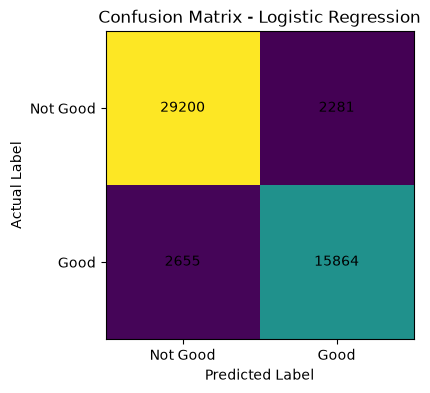

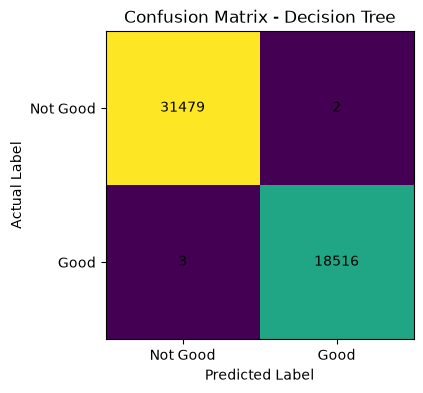

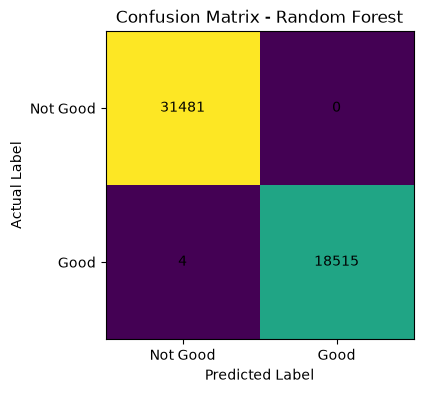

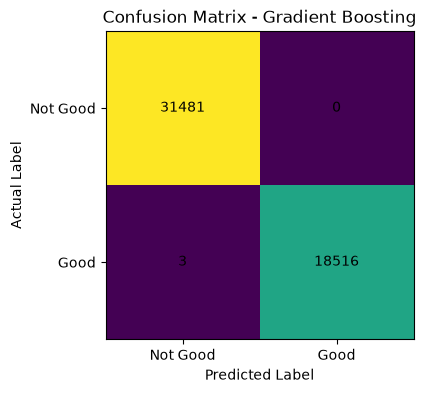

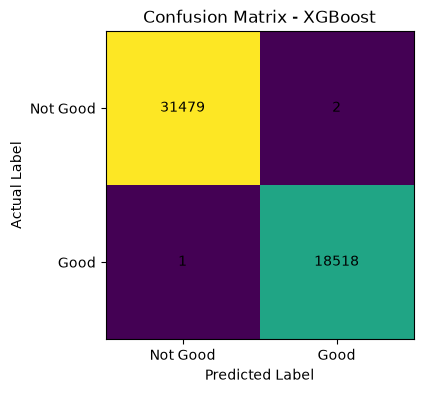

In [75]:
# CONFUSION MATRICES FOR ALL 5 MODELS

# Import confusion_matrix and matplotlib.
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Store predictions from all five models.
predictions = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb,
    "XGBoost": y_pred_xgb
}

# Create a confusion matrix for each model.
for model_name, predictions_model in predictions.items():

    # Calculate the confusion matrix.
    cm = confusion_matrix(
        y_test,
        predictions_model
    )

    # Create a separate figure for each model.
    plt.figure(figsize=(5, 4))

    # Display the confusion matrix as an image.
    plt.imshow(cm)

    # Add the numbers inside the matrix.
    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    # Add axis labels.
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    # Add the model name as the title.
    plt.title(f"Confusion Matrix - {model_name}")

    # Add class labels.
    plt.xticks([0, 1], ["Not Good", "Good"])
    plt.yticks([0, 1], ["Not Good", "Good"])

    # Display the confusion matrix.
    plt.show()

# REGRESSION MODEL

## Fixed Rate: Future = Current * (1 + r)^t (e.g., r=8%)


In [76]:
# STEP 4.1: CREATE FUTURE PRICE AFTER 5 YEARS

# Define the annual appreciation rate.
# According to our project specification, we assume 8% growth
# in property price every year.
annual_growth_rate = 0.08

# Define the number of years for future price prediction.
years = 5

# Calculate the future property price after 5 years.
#
# Formula:
# Future Price = Current Price * (1 + r)^t
#
# Price_in_Lakhs currently contains the property price
# in rupees.
df["Future_Price_5Y"] = (
    df["Price_in_Lakhs"]
    * (1 + annual_growth_rate) ** years
)

# Display the current price and calculated future price
# for the first 10 properties.
print("Current Price vs Future Price After 5 Years")
print("--------------------------------------------")

print(
    df[
        [
            "Price_in_Lakhs",
            "Future_Price_5Y"
        ]
    ].head(10)
)

# Display the assumptions used for the calculation.
print("\nAnnual Appreciation Rate:", annual_growth_rate * 100, "%")
print("Prediction Period:", years, "years")

# Display basic statistics of the new target variable.
print("\nFuture_Price_5Y Statistics")
print("---------------------------")
print(df["Future_Price_5Y"].describe())

Current Price vs Future Price After 5 Years
--------------------------------------------
   Price_in_Lakhs  Future_Price_5Y
0        48976000     7.196181e+07
1        19552000     2.872830e+07
2        18379000     2.700478e+07
3        30029000     4.412245e+07
4        18290000     2.687401e+07
5        13528000     1.987707e+07
6        31812000     4.674226e+07
7        14138999     2.077483e+07
8        18916000     2.779381e+07
9        18742000     2.753815e+07

Annual Appreciation Rate: 8.0 %
Prediction Period: 5 years

Future_Price_5Y Statistics
---------------------------
count    2.500000e+05
mean     3.740716e+07
std      2.076894e+07
min      1.469328e+06
25%      1.947594e+07
50%      3.730183e+07
75%      5.537604e+07
max      7.346640e+07
Name: Future_Price_5Y, dtype: float64


In [77]:
# Convert Future_Price_5Y to integer values
df["Future_Price_5Y"] = df["Future_Price_5Y"].round().astype("int64")

# Display the values in normal integer format
print(df[[
    "Price_in_Lakhs",
    "Future_Price_5Y"
]].head(10))

   Price_in_Lakhs  Future_Price_5Y
0        48976000         71961812
1        19552000         28728303
2        18379000         27004781
3        30029000         44122453
4        18290000         26874011
5        13528000         19877070
6        31812000         46742265
7        14138999         20774828
8        18916000         27793810
9        18742000         27538147


In [78]:
# ---------------------------------------------------------
# STEP 4.2: PREPARE X AND y FOR REGRESSION
# ---------------------------------------------------------

# Create the target variable.
# y contains the future property price that our regression
# models will learn to predict.
y_reg = df["Future_Price_5Y"]

# Columns that should NOT be used as regression features.
#
# ID is only an identifier.
# Future_Price_5Y is our target, so it cannot be an input.
# Good_Investment and Investment_Score belong to the
# classification task and should not be used here.
#
# Original categorical columns are removed because their
# one-hot encoded versions are already present.
columns_to_drop_reg = [
    "ID",
    "Future_Price_5Y",
    "Good_Investment",
    "Investment_Score",
    "State",
    "City",
    "Locality",
    "Property_Type",
    "Furnished_Status",
    "Public_Transport_Accessibility",
    "Amenities",
    "Facing",
    "Owner_Type"
]

# Create X by removing the unwanted columns.
X_reg = df.drop(
    columns=columns_to_drop_reg
)

# Display the shape of X and y.
print("X_reg shape:", X_reg.shape)
print("y_reg shape:", y_reg.shape)

# Display the features used for regression.
print("\nFeatures used for regression:")
print(X_reg.columns.tolist())

# Display basic statistics of the target variable.
print("\nFuture_Price_5Y Statistics:")
print(y_reg.describe())

X_reg shape: (250000, 36)
y_reg shape: (250000,)

Features used for regression:
['BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Parking_Space', 'Security', 'Availability_Status', 'Playground', 'Gym', 'Garden', 'Pool', 'Clubhouse', 'Amenity_Count', 'Locality_Frequency', 'Furnished_Status_Furnished', 'Furnished_Status_Semi-furnished', 'Furnished_Status_Unfurnished', 'Property_Type_Apartment', 'Property_Type_Independent House', 'Property_Type_Villa', 'Public_Transport_Accessibility_High', 'Public_Transport_Accessibility_Low', 'Public_Transport_Accessibility_Medium', 'Facing_East', 'Facing_North', 'Facing_South', 'Facing_West', 'Owner_Type_Broker', 'Owner_Type_Builder', 'Owner_Type_Owner']

Future_Price_5Y Statistics:
count    2.500000e+05
mean     3.740716e+07
std      2.076894e+07
min      1.469328e+06
25%      1.947594e+07
50%      3.730183e+07
75%      5.537604e+07
max      7

In [79]:
# ---------------------------------------------------------
# STEP 4.3: TRAIN-TEST SPLIT FOR REGRESSION
# ---------------------------------------------------------

# Import train_test_split from scikit-learn.
from sklearn.model_selection import train_test_split

# Split the regression data into training and testing sets.
#
# test_size=0.20 means 20% of the data will be used
# for testing and 80% for training.
#
# random_state=42 ensures that the same split is obtained
# every time the code is executed.
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Display the shapes of the resulting datasets.
print("X_train_reg shape:", X_train_reg.shape)
print("X_test_reg shape :", X_test_reg.shape)
print("y_train_reg shape:", y_train_reg.shape)
print("y_test_reg shape :", y_test_reg.shape)

# Display a few target values from the training data.
print("\nFirst 10 training target values:")
print(y_train_reg.head(10))

# Display a few target values from the testing data.
print("\nFirst 10 testing target values:")
print(y_test_reg.head(10))

X_train_reg shape: (200000, 36)
X_test_reg shape : (50000, 36)
y_train_reg shape: (200000,)
y_test_reg shape : (50000,)

First 10 training target values:
75381      5628996
65569      9415454
163473    39228121
90518     18955802
138866     9571203
222390     4008327
57189     47169838
85175      5432106
181156    34479253
49143     46158940
Name: Future_Price_5Y, dtype: int64

First 10 testing target values:
38683     37705897
64939     12642099
3954      34949438
120374    49870464
172861    18365132
149303     5167627
111626    40516722
164553    55064539
55779     69991443
141990    30562024
Name: Future_Price_5Y, dtype: int64


In [80]:
# ---------------------------------------------------------
# STEP 4.4: FEATURE SCALING FOR REGRESSION
# ---------------------------------------------------------

# Import StandardScaler from scikit-learn.
from sklearn.preprocessing import StandardScaler

# Create the StandardScaler object.
scaler_reg = StandardScaler()

# Fit the scaler only on the training features.
# The scaler learns the mean and standard deviation
# from X_train_reg.
X_train_reg_scaled = scaler_reg.fit_transform(
    X_train_reg
)

# Use the same fitted scaler to transform the test features.
# We do NOT fit the scaler again on X_test_reg.
X_test_reg_scaled = scaler_reg.transform(
    X_test_reg
)

# Display the shapes after scaling.
print("X_train_reg_scaled shape:", X_train_reg_scaled.shape)
print("X_test_reg_scaled shape :", X_test_reg_scaled.shape)

# Display a few scaled values.
print("\nFirst 5 rows of scaled training data:")
print(X_train_reg_scaled[:5])

X_train_reg_scaled shape: (200000, 36)
X_test_reg_scaled shape : (50000, 36)

First 5 rows of scaled training data:
[[ 1.41325042e+00  1.10757213e+00 -1.52943546e+00 -9.28720853e-01
  -1.07103414e+00 -7.76763180e-01 -8.77501175e-01  1.07103414e+00
  -1.21564536e+00 -1.21784509e+00 -9.96615727e-01 -1.00038007e+00
   1.00003000e+00 -1.22283330e+00 -1.22511492e+00  8.15093950e-01
   8.16062886e-01 -1.22705708e+00 -7.08240527e-01  8.88810966e-02
  -7.06799212e-01  1.41443103e+00 -7.07523131e-01  1.42083665e+00
  -7.07316272e-01 -7.10198220e-01 -7.08748790e-01  1.41315886e+00
  -7.04938834e-01 -5.74902293e-01 -5.77319477e-01 -5.77057745e-01
   1.72377663e+00  1.41295231e+00 -7.07061704e-01 -7.06520847e-01]
 [-7.05798781e-01  1.46277923e+00 -1.34717197e+00 -8.93304031e-01
   1.37336914e+00 -4.41361138e-01 -1.29432212e+00 -1.37336914e+00
   1.56313934e+00  1.75787601e-01  1.00339577e+00 -1.00038007e+00
   1.00003000e+00 -1.22283330e+00 -1.22511492e+00 -1.22685244e+00
   8.16062886e-01  8.1495

## Linear Regression

In [81]:
# ---------------------------------------------------------
# STEP 4.5: LINEAR REGRESSION
# ---------------------------------------------------------

# Import Linear Regression from scikit-learn.
from sklearn.linear_model import LinearRegression

# Import regression evaluation metrics.
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Import NumPy for calculating RMSE.
import numpy as np

# Create the Linear Regression model.
linear_model = LinearRegression()

# Train the Linear Regression model using
# the scaled training features.
linear_model.fit(
    X_train_reg_scaled,
    y_train_reg
)

# Predict future prices for the test data.
y_pred_linear = linear_model.predict(
    X_test_reg_scaled
)

# Calculate Mean Absolute Error (MAE).
# MAE represents the average absolute difference
# between actual and predicted prices.
linear_mae = mean_absolute_error(
    y_test_reg,
    y_pred_linear
)

# Calculate Mean Squared Error (MSE).
linear_mse = mean_squared_error(
    y_test_reg,
    y_pred_linear
)

# Calculate Root Mean Squared Error (RMSE).
# RMSE gives the error in the same unit as the target.
linear_rmse = np.sqrt(linear_mse)

# Calculate R² Score.
# R² shows how much variation in future price
# is explained by the model.
linear_r2 = r2_score(
    y_test_reg,
    y_pred_linear
)

# Display the results.
print("Linear Regression Results")
print("-------------------------")
print("MAE  :", round(linear_mae, 2))
print("RMSE :", round(linear_rmse, 2))
print("R²   :", round(linear_r2, 4))

regression_run_ids["Linear Regression"] = log_regression_run(
    "Linear Regression", linear_model, linear_mae, linear_rmse, linear_r2
)

Linear Regression Results
-------------------------
MAE  : 0.25
RMSE : 0.29
R²   : 1.0
Logged run: Linear Regression (run_id=aab7bb71b0884523b072fd550e73f82f)


## Decision Tree Regressor

In [82]:
# ---------------------------------------------------------
# STEP 4.6: DECISION TREE REGRESSOR
# ---------------------------------------------------------

# Import Decision Tree Regressor.
from sklearn.tree import DecisionTreeRegressor

# Import regression evaluation metrics.
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Import NumPy for calculating RMSE.
import numpy as np

# Create the Decision Tree Regressor.
#
# max_depth=10 limits the depth of the tree
# and helps control overfitting.
#
# random_state=42 ensures reproducible results.
decision_tree_reg = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

# Train the model using the original,
# unscaled training features.
decision_tree_reg.fit(
    X_train_reg,
    y_train_reg
)

# Predict future prices using the test data.
y_pred_tree_reg = decision_tree_reg.predict(
    X_test_reg
)

# Calculate Mean Absolute Error.
tree_reg_mae = mean_absolute_error(
    y_test_reg,
    y_pred_tree_reg
)

# Calculate Mean Squared Error.
tree_reg_mse = mean_squared_error(
    y_test_reg,
    y_pred_tree_reg
)

# Calculate Root Mean Squared Error.
tree_reg_rmse = np.sqrt(tree_reg_mse)

# Calculate R² Score.
tree_reg_r2 = r2_score(
    y_test_reg,
    y_pred_tree_reg
)

# Display the results.
print("Decision Tree Regressor Results")
print("--------------------------------")
print("MAE :", round(tree_reg_mae, 2))
print("RMSE:", round(tree_reg_rmse, 2))
print("R²  :", round(tree_reg_r2, 4))


regression_run_ids["Decision Tree"] = log_regression_run(
    "Decision Tree", decision_tree_reg, tree_reg_mae, tree_reg_rmse, tree_reg_r2
)

Decision Tree Regressor Results
--------------------------------
MAE : 17589.47
RMSE: 20370.6
R²  : 1.0
Logged run: Decision Tree (run_id=8aa9f96e2ab64f87867e430dd8003f78)


## RANDOM FOREST REGRESSOR


In [83]:
# ---------------------------------------------------------
# STEP 4.7: RANDOM FOREST REGRESSOR
# ---------------------------------------------------------

# Import Random Forest Regressor.
from sklearn.ensemble import RandomForestRegressor

# Import regression evaluation metrics.
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Import NumPy for calculating RMSE.
import numpy as np

# Create the Random Forest Regressor.
#
# n_estimators=100 means the model will build 100 decision trees.
# random_state=42 ensures reproducible results.
# n_jobs=-1 uses all available CPU cores to speed up training.
random_forest_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model using the original, unscaled features.
#
# Tree-based models do not require feature scaling.
random_forest_reg.fit(
    X_train_reg,
    y_train_reg
)

# Predict future prices using the test data.
y_pred_rf_reg = random_forest_reg.predict(
    X_test_reg
)

# Calculate Mean Absolute Error.
rf_reg_mae = mean_absolute_error(
    y_test_reg,
    y_pred_rf_reg
)

# Calculate Mean Squared Error.
rf_reg_mse = mean_squared_error(
    y_test_reg,
    y_pred_rf_reg
)

# Calculate Root Mean Squared Error.
rf_reg_rmse = np.sqrt(rf_reg_mse)

# Calculate R² Score.
rf_reg_r2 = r2_score(
    y_test_reg,
    y_pred_rf_reg
)

# Display the results.
print("Random Forest Regressor Results")
print("--------------------------------")
print("MAE :", round(rf_reg_mae, 2))
print("RMSE:", round(rf_reg_rmse, 2))
print("R²  :", round(rf_reg_r2, 4))

regression_run_ids["Random Forest"] = log_regression_run(
    "Random Forest", random_forest_reg, rf_reg_mae, rf_reg_rmse, rf_reg_r2
)

Random Forest Regressor Results
--------------------------------
MAE : 207.19
RMSE: 327.23
R²  : 1.0
Logged run: Random Forest (run_id=3575875e04514f699c80874b475f23e0)


## Gradient Boosting Regressor.

In [84]:
# STEP 4.8: GRADIENT BOOSTING REGRESSOR
# ---------------------------------------------------------

# Import Gradient Boosting Regressor.
from sklearn.ensemble import GradientBoostingRegressor

# Import regression evaluation metrics.
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Import NumPy for calculating RMSE.
import numpy as np

# Create the Gradient Boosting Regressor.
#
# n_estimators=100 means 100 boosting stages will be created.
# learning_rate=0.1 controls how much each tree contributes.
# max_depth=3 keeps individual trees relatively simple.
# random_state=42 makes the result reproducible.
gradient_boosting_reg = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the model using the original, unscaled features.
#
# Scaling is not required for tree-based models.
gradient_boosting_reg.fit(
    X_train_reg,
    y_train_reg
)

# Predict future prices using the test data.
y_pred_gb_reg = gradient_boosting_reg.predict(
    X_test_reg
)

# Calculate Mean Absolute Error.
gb_reg_mae = mean_absolute_error(
    y_test_reg,
    y_pred_gb_reg
)

# Calculate Mean Squared Error.
gb_reg_mse = mean_squared_error(
    y_test_reg,
    y_pred_gb_reg
)

# Calculate Root Mean Squared Error.
gb_reg_rmse = np.sqrt(gb_reg_mse)

# Calculate R² Score.
gb_reg_r2 = r2_score(
    y_test_reg,
    y_pred_gb_reg
)

# Display the results.
print("Gradient Boosting Regressor Results")
print("-----------------------------------")
print("MAE :", round(gb_reg_mae, 2))
print("RMSE:", round(gb_reg_rmse, 2))
print("R²  :", round(gb_reg_r2, 4))

regression_run_ids["Gradient Boosting"] = log_regression_run(
    "Gradient Boosting", gradient_boosting_reg, gb_reg_mae, gb_reg_rmse, gb_reg_r2
)

Gradient Boosting Regressor Results
-----------------------------------
MAE : 107507.16
RMSE: 142109.96
R²  : 1.0
Logged run: Gradient Boosting (run_id=a9e68e212c2944bca27bde3e95baee8c)


## XGBoost Regressor.

In [85]:
# ---------------------------------------------------------
# STEP 4.9: XGBOOST REGRESSOR
# ---------------------------------------------------------

# Import XGBoost Regressor.
from xgboost import XGBRegressor

# Import regression evaluation metrics.
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Import NumPy for calculating RMSE.
import numpy as np

# Create the XGBoost Regressor.
#
# n_estimators=100 -> number of boosting trees.
# learning_rate=0.1 -> contribution of each tree.
# max_depth=6 -> maximum depth of each tree.
# random_state=42 -> makes results reproducible.
# n_jobs=-1 -> uses all available CPU cores.
xgb_reg = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

# Train the model using the original, unscaled features.
#
# XGBoost is a tree-based model, so scaling is not required.
xgb_reg.fit(
    X_train_reg,
    y_train_reg
)

# Predict future prices using the test data.
y_pred_xgb_reg = xgb_reg.predict(
    X_test_reg
)

# Calculate Mean Absolute Error.
xgb_reg_mae = mean_absolute_error(
    y_test_reg,
    y_pred_xgb_reg
)

# Calculate Mean Squared Error.
xgb_reg_mse = mean_squared_error(
    y_test_reg,
    y_pred_xgb_reg
)

# Calculate Root Mean Squared Error.
xgb_reg_rmse = np.sqrt(xgb_reg_mse)

# Calculate R² Score.
xgb_reg_r2 = r2_score(
    y_test_reg,
    y_pred_xgb_reg
)

# Display the results.
print("XGBoost Regressor Results")
print("-------------------------")
print("MAE :", round(xgb_reg_mae, 2))
print("RMSE:", round(xgb_reg_rmse, 2))
print("R²  :", round(xgb_reg_r2, 4))

regression_run_ids["XGBoost"] = log_regression_run(
    "XGBoost", xgb_reg, xgb_reg_mae, xgb_reg_rmse, xgb_reg_r2
)

XGBoost Regressor Results
-------------------------
MAE : 70491.91
RMSE: 81495.63
R²  : 1.0
Logged run: XGBoost (run_id=8723c94502a542e5b215f733e5cfcf14)


## REGRESSION MODEL COMPARISON


In [86]:
# STEP 4.10: REGRESSION MODEL COMPARISON

# Create a dictionary containing the results
# of all five regression models.
regression_results = {
    "Linear Regression": [
        linear_mae,
        linear_rmse,
        linear_r2
    ],

    "Decision Tree": [
        tree_reg_mae,
        tree_reg_rmse,
        tree_reg_r2
    ],

    "Random Forest": [
        rf_reg_mae,
        rf_reg_rmse,
        rf_reg_r2
    ],

    "Gradient Boosting": [
        gb_reg_mae,
        gb_reg_rmse,
        gb_reg_r2
    ],

    "XGBoost": [
        xgb_reg_mae,
        xgb_reg_rmse,
        xgb_reg_r2
    ]
}

# Convert the dictionary into a DataFrame.
comparison_reg_df = pd.DataFrame(
    regression_results,
    index=["MAE", "RMSE", "R²"]
).T

# Display the comparison table.
print("Regression Model Comparison")
print("---------------------------")
print(comparison_reg_df.round(2))

# Find the model with the lowest MAE.
best_mae_model = comparison_reg_df["MAE"].idxmin()

# Find the model with the lowest RMSE.
best_rmse_model = comparison_reg_df["RMSE"].idxmin()

# Find the model with the highest R².
best_r2_model = comparison_reg_df["R²"].idxmax()

# Display the best models according to each metric.
print("\nBest Model based on MAE :", best_mae_model)
print("Best Model based on RMSE:", best_rmse_model)
print("Best Model based on R²  :", best_r2_model)

Regression Model Comparison
---------------------------
                         MAE       RMSE   R²
Linear Regression       0.25       0.29  1.0
Decision Tree       17589.47   20370.60  1.0
Random Forest         207.19     327.23  1.0
Gradient Boosting  107507.16  142109.96  1.0
XGBoost             70491.91   81495.63  1.0

Best Model based on MAE : Linear Regression
Best Model based on RMSE: Linear Regression
Best Model based on R²  : Linear Regression


## ml flow

In [87]:
best_clf_name = comparison_df.loc[comparison_df["F1 Score"].idxmax(), "Model"]
best_clf_run_id = classification_run_ids[best_clf_name]

mlflow.register_model(
    f"runs:/{best_clf_run_id}/model",
    "GoodInvestment_Classifier"
)
print(f"Registered classifier: {best_clf_name} (run_id={best_clf_run_id})")

best_reg_name = comparison_reg_df["RMSE"].idxmin()
best_reg_run_id = regression_run_ids[best_reg_name]

mlflow.register_model(
    f"runs:/{best_reg_run_id}/model",
    "FuturePrice5Y_Regressor"
)
print(f"Registered regressor: {best_reg_name} (run_id={best_reg_run_id})")

Registered model 'GoodInvestment_Classifier' already exists. Creating a new version of this model...
2026/09/10 18:35:27 WARNING mlflow.tracking._model_registry.fluent: Run with id c9e183cc37054634ba1599e57ae2aed9 has no artifacts at artifact path 'model', registering model based on models:/m-e2c2a47f46694095ac19437611a2141e instead
Created version '3' of model 'GoodInvestment_Classifier'.
Registered model 'FuturePrice5Y_Regressor' already exists. Creating a new version of this model...


Registered classifier: Decision Tree (run_id=c9e183cc37054634ba1599e57ae2aed9)


2026/09/10 18:35:27 WARNING mlflow.tracking._model_registry.fluent: Run with id aab7bb71b0884523b072fd550e73f82f has no artifacts at artifact path 'model', registering model based on models:/m-3ed9626b41a24bc781a0e540e7cb5130 instead


Registered regressor: Linear Regression (run_id=aab7bb71b0884523b072fd550e73f82f)


Created version '4' of model 'FuturePrice5Y_Regressor'.


In [88]:
classifier = mlflow.pyfunc.load_model("models:/GoodInvestment_Classifier@champion")
regressor = mlflow.pyfunc.load_model("models:/FuturePrice5Y_Regressor@champion")

classifier.predict(X_test)
regressor.predict(X_test_reg_scaled)   # ← use the scaled version instead

D:\anacoda\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([1470753.14, 1471238.01, 1471164.58, ..., 1470797.22, 1470900.06,
       1471311.5 ], shape=(50000,))

In [89]:
from sklearn.pipeline import Pipeline

# Wrap the scaler + trained model together
regression_pipeline = Pipeline([
    ("scaler", scaler_reg),
    ("model", linear_model)
])

# Log this pipeline instead of the raw model
with mlflow.start_run(run_name="Linear Regression (pipeline)"):
    mlflow.log_metrics({"mae": linear_mae, "rmse": linear_rmse, "r2": linear_r2})
    mlflow.sklearn.log_model(regression_pipeline, name="model")

In [90]:
# ---------------------------------------------------------
# STEP 4.0: ONE-HOT ENCODE CITY (needed for location-based growth rates)
# ---------------------------------------------------------

city_dummies = pd.get_dummies(df["City"], prefix="City").astype(int)
df = pd.concat([df, city_dummies], axis=1)

print("Added", city_dummies.shape[1], "city columns.")
print(city_dummies.columns.tolist()[:5], "...")

Added 42 city columns.
['City_Ahmedabad', 'City_Amritsar', 'City_Bangalore', 'City_Bhopal', 'City_Bhubaneswar'] ...


In [91]:
# ---------------------------------------------------------
# STEP 4.1: CREATE FUTURE PRICE AFTER 5 YEARS (By Location/Type)
# ---------------------------------------------------------

# City tiers -> base annual growth rate.
# Tier 1: major metros, historically faster appreciation.
# Tier 2: strong secondary cities.
# Tier 3: smaller/emerging cities.
tier_1_cities = ["Mumbai", "New Delhi", "Delhi", "Bangalore", "Hyderabad",
                  "Pune", "Chennai", "Gurgaon", "Noida"]

tier_2_cities = ["Ahmedabad", "Kolkata", "Jaipur", "Lucknow", "Surat",
                  "Nagpur", "Indore", "Bhopal", "Coimbatore", "Kochi",
                  "Vijayawada", "Vishakhapatnam", "Mysore", "Trivandrum",
                  "Faridabad", "Dwarka"]

# Anything not in tier 1 or 2 falls into tier 3.

def get_city_growth_rate(city):
    if city in tier_1_cities:
        return 0.10
    elif city in tier_2_cities:
        return 0.07
    else:
        return 0.05

df["City_Base_Rate"] = df["City"].apply(get_city_growth_rate)

# Property type adjustment on top of the city base rate.
property_type_adjustment = {
    "Villa": 0.015,
    "Independent House": 0.005,
    "Apartment": 0.0
}

df["Type_Adjustment"] = df["Property_Type"].map(property_type_adjustment)

# Final growth rate per property.
df["Growth_Rate"] = df["City_Base_Rate"] + df["Type_Adjustment"]

years = 5

df["Future_Price_5Y"] = (
    df["Price_in_Lakhs"] * (1 + df["Growth_Rate"]) ** years
)

df["Future_Price_5Y"] = df["Future_Price_5Y"].round().astype("int64")

# Display results.
print("Current Price vs Future Price After 5 Years")
print("--------------------------------------------")
print(df[["City", "Property_Type", "Growth_Rate", "Price_in_Lakhs", "Future_Price_5Y"]].head(10))

print("\nGrowth Rate Distribution:")
print(df["Growth_Rate"].value_counts().sort_index())

print("\nFuture_Price_5Y Statistics")
print("---------------------------")
print(df["Future_Price_5Y"].describe())

Current Price vs Future Price After 5 Years
--------------------------------------------
         City      Property_Type  Growth_Rate  Price_in_Lakhs  Future_Price_5Y
0     Chennai          Apartment        0.100        48976000         78876338
1        Pune  Independent House        0.105        19552000         32210879
2    Ludhiana          Apartment        0.050        18379000         23456779
3     Jodhpur  Independent House        0.055        30029000         39246702
4      Jaipur              Villa        0.085        18290000         27501881
5    Durgapur          Apartment        0.050        13528000         17265537
6  Coimbatore  Independent House        0.075        31812000         45670240
7    Bilaspur  Independent House        0.055        14138999         18479106
8   New Delhi              Villa        0.115        18916000         32598952
9      Ranchi              Villa        0.065        18742000         25678164

Growth Rate Distribution:
Growth_Rate
0.0

In [92]:
# ---------------------------------------------------------
# STEP 4.2: PREPARE X AND y FOR REGRESSION
# ---------------------------------------------------------

y_reg = df["Future_Price_5Y"]

columns_to_drop_reg = [
    "ID",
    "Future_Price_5Y",
    "Good_Investment",
    "Investment_Score",
    "City_Base_Rate",     # helper column, not a real feature
    "Type_Adjustment",    # helper column, not a real feature
    "Growth_Rate",        # this WOULD be leakage — drop it
    "State",
    "City",               # raw text version — we use the one-hot City_* columns instead
    "Locality",
    "Property_Type",
    "Furnished_Status",
    "Public_Transport_Accessibility",
    "Amenities",
    "Facing",
    "Owner_Type"
]

X_reg = df.drop(columns=columns_to_drop_reg)

print("X_reg shape:", X_reg.shape)
print("y_reg shape:", y_reg.shape)
print("\nFeatures used for regression:")
print(X_reg.columns.tolist())

X_reg shape: (250000, 78)
y_reg shape: (250000,)

Features used for regression:
['BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Parking_Space', 'Security', 'Availability_Status', 'Playground', 'Gym', 'Garden', 'Pool', 'Clubhouse', 'Amenity_Count', 'Locality_Frequency', 'Furnished_Status_Furnished', 'Furnished_Status_Semi-furnished', 'Furnished_Status_Unfurnished', 'Property_Type_Apartment', 'Property_Type_Independent House', 'Property_Type_Villa', 'Public_Transport_Accessibility_High', 'Public_Transport_Accessibility_Low', 'Public_Transport_Accessibility_Medium', 'Facing_East', 'Facing_North', 'Facing_South', 'Facing_West', 'Owner_Type_Broker', 'Owner_Type_Builder', 'Owner_Type_Owner', 'City_Ahmedabad', 'City_Amritsar', 'City_Bangalore', 'City_Bhopal', 'City_Bhubaneswar', 'City_Bilaspur', 'City_Chennai', 'City_Coimbatore', 'City_Cuttack', 'City_Dehradun', 'City_Durgapur', 'Ci

In [93]:
# ============================================================
# EXPORT EVERYTHING THE STREAMLIT APP NEEDS
# Run this ONCE, in this same kernel, while everything is still
# in memory. Do NOT re-run cells above this after running it,
# or X_train / scaler_reg etc. may no longer match what was
# actually registered.
# ============================================================
import os
import json
import joblib
from mlflow.tracking import MlflowClient

ARTIFACT_DIR = "streamlit_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

client = MlflowClient()

# ---- 1. Actually set the @champion alias (this was never done anywhere) ----
clf_version = client.get_model_version_by_alias  # noqa (just checking the API exists)

def set_champion_by_run_id(model_name, run_id):
    # Find which registered version corresponds to this run_id
    for mv in client.search_model_versions(f"name='{model_name}'"):
        if mv.run_id == run_id:
            client.set_registered_model_alias(model_name, "champion", mv.version)
            print(f"Set 'champion' alias on {model_name} v{mv.version} (run_id={run_id})")
            return
    raise ValueError(f"No version of {model_name} found for run_id {run_id}")

set_champion_by_run_id("GoodInvestment_Classifier", best_clf_run_id)
set_champion_by_run_id("FuturePrice5Y_Regressor", best_reg_run_id)

# ---- 2. Save the scalers (these were never persisted anywhere) ----
joblib.dump(scaler, f"{ARTIFACT_DIR}/scaler_clf.joblib")        # unused by Decision Tree champion, saved for future use
joblib.dump(scaler_reg, f"{ARTIFACT_DIR}/scaler_reg.joblib")    # REQUIRED - Linear Regression champion needs this

# ---- 3. Save the exact feature lists the champions were actually fit on ----
# Pulled from X_train / X_train_reg directly (not X / X_reg, which get
# reassigned later in this notebook) so this can't drift.
clf_features = X_train.columns.tolist()
reg_features = X_train_reg.columns.tolist()

with open(f"{ARTIFACT_DIR}/classification_features.json", "w") as f:
    json.dump(clf_features, f)
with open(f"{ARTIFACT_DIR}/regression_features.json", "w") as f:
    json.dump(reg_features, f)

print("Classification features:", len(clf_features))
print("Regression features:", len(reg_features))

# ---- 4. Record which champion needs scaling, explicitly ----
# (type(model).__name__ can't be trusted once loaded via mlflow.pyfunc,
# so we record this ourselves instead of detecting it at runtime.)
model_meta = {
    "classifier_model_name": type(decision_tree_model).__name__,
    "classifier_needs_scaling": False,
    "regressor_model_name": type(linear_model).__name__,
    "regressor_needs_scaling": True,
}
with open(f"{ARTIFACT_DIR}/model_meta.json", "w") as f:
    json.dump(model_meta, f)

# ---- 5. Dropdown options + locality frequency + sensible defaults ----
dropdowns = {
    "City": sorted(df["City"].unique().tolist()),
    "State": sorted(df["State"].unique().tolist()),
    "Locality": sorted(df["Locality"].unique().tolist()),
    "Property_Type": sorted(df["Property_Type"].unique().tolist()),
    "Furnished_Status": sorted(df["Furnished_Status"].unique().tolist()),
    "Facing": sorted(df["Facing"].unique().tolist()),
    "Owner_Type": sorted(df["Owner_Type"].unique().tolist()),
    "Public_Transport_Accessibility": sorted(df["Public_Transport_Accessibility"].unique().tolist()),
}
with open(f"{ARTIFACT_DIR}/dropdown_options.json", "w") as f:
    json.dump(dropdowns, f)

locality_freq_dict = df["Locality"].value_counts().to_dict()
with open(f"{ARTIFACT_DIR}/locality_frequency.json", "w") as f:
    json.dump(locality_freq_dict, f)

defaults = {
    "median_locality_freq": float(df["Locality"].value_counts().median()),
}
with open(f"{ARTIFACT_DIR}/defaults.json", "w") as f:
    json.dump(defaults, f)

# ---- 6. Small samples for the Browse / Insights tabs (avoid shipping 250k rows) ----
sample_cols = ["City", "State", "Locality", "Property_Type", "BHK", "Size_in_SqFt",
               "Price_in_Lakhs", "Price_per_SqFt", "Furnished_Status", "Facing",
               "Owner_Type", "Availability_Status", "Good_Investment", "Age_of_Property"]
df[sample_cols].sample(min(20000, len(df)), random_state=42).to_csv(
    f"{ARTIFACT_DIR}/property_sample.csv", index=False
)
city_summary = df.groupby("City").agg(
    Avg_Price=("Price_in_Lakhs", "mean"),
    Avg_Price_per_SqFt=("Price_per_SqFt", "mean"),
    Good_Investment_Rate=("Good_Investment", "mean"),
).reset_index()
city_summary.to_csv(f"{ARTIFACT_DIR}/city_price_summary.csv", index=False)

print("\nAll artifacts saved to:", os.path.abspath(ARTIFACT_DIR))

Set 'champion' alias on GoodInvestment_Classifier v3 (run_id=c9e183cc37054634ba1599e57ae2aed9)
Set 'champion' alias on FuturePrice5Y_Regressor v4 (run_id=aab7bb71b0884523b072fd550e73f82f)
Classification features: 36
Regression features: 36

All artifacts saved to: C:\Users\HP\streamlit_artifacts


In [94]:
# ============================================================
# ADDITIONAL EXPORT: defaults for fields hidden from the form
# Run this AFTER the export cell you already ran, same live kernel.
# ============================================================
import json

# City -> State is a fixed lookup in your data (each city belongs to
# exactly one state), so State can be derived automatically from
# whichever City the user picks, instead of being a separate field.
city_to_state = df.groupby("City")["State"].agg(lambda s: s.mode()[0]).to_dict()
with open(f"{ARTIFACT_DIR}/city_to_state.json", "w") as f:
    json.dump(city_to_state, f)

# NOTE: at this point in your notebook, Security and Availability_Status
# were already converted to 0/1 (cell 24), so their .mode() gives you the
# encoded value directly - no text mapping needed for these two.
hidden_defaults = {
    "Furnished_Status": df["Furnished_Status"].mode()[0],      # raw category text (e.g. "Furnished")
    "Facing": df["Facing"].mode()[0],                            # raw category text
    "Owner_Type": df["Owner_Type"].mode()[0],                    # raw category text
    "Availability_Status_encoded": int(df["Availability_Status"].mode()[0]),  # already 0/1
    "Security_encoded": int(df["Security"].mode()[0]),           # already 0/1
    "Year_Built": int(df["Year_Built"].median()),
    "Floor_No": int(df["Floor_No"].median()),
    "Total_Floors": int(df["Total_Floors"].median()),
}
with open(f"{ARTIFACT_DIR}/hidden_defaults.json", "w") as f:
    json.dump(hidden_defaults, f)

print("Hidden defaults:", hidden_defaults)
print("City -> State entries:", len(city_to_state))

Hidden defaults: {'Furnished_Status': 'Unfurnished', 'Facing': 'West', 'Owner_Type': 'Broker', 'Availability_Status_encoded': 0, 'Security_encoded': 1, 'Year_Built': 2007, 'Floor_No': 15, 'Total_Floors': 22}
City -> State entries: 42


In [95]:
# ============================================================
# EXPORT EVERYTHING THE STREAMLIT APP NEEDS - run this once
# ============================================================
import os
import json
import joblib
from mlflow.tracking import MlflowClient

ARTIFACT_DIR = "streamlit_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

client = MlflowClient()

def set_champion_by_run_id(model_name, run_id):
    for mv in client.search_model_versions(f"name='{model_name}'"):
        if mv.run_id == run_id:
            client.set_registered_model_alias(model_name, "champion", mv.version)
            print(f"Set 'champion' alias on {model_name} v{mv.version} (run_id={run_id})")
            return
    raise ValueError(f"No version of {model_name} found for run_id {run_id}")

set_champion_by_run_id("GoodInvestment_Classifier", best_clf_run_id)
set_champion_by_run_id("FuturePrice5Y_Regressor", best_reg_run_id)

joblib.dump(scaler, f"{ARTIFACT_DIR}/scaler_clf.joblib")
joblib.dump(scaler_reg, f"{ARTIFACT_DIR}/scaler_reg.joblib")

clf_features = X_train.columns.tolist()
reg_features = X_train_reg.columns.tolist()
with open(f"{ARTIFACT_DIR}/classification_features.json", "w") as f:
    json.dump(clf_features, f)
with open(f"{ARTIFACT_DIR}/regression_features.json", "w") as f:
    json.dump(reg_features, f)

model_meta = {
    "classifier_model_name": type(decision_tree_model).__name__,
    "classifier_needs_scaling": False,
    "regressor_model_name": type(linear_model).__name__,
    "regressor_needs_scaling": True,
}
with open(f"{ARTIFACT_DIR}/model_meta.json", "w") as f:
    json.dump(model_meta, f)

dropdowns = {
    "City": sorted(df["City"].unique().tolist()),
    "State": sorted(df["State"].unique().tolist()),
    "Locality": sorted(df["Locality"].unique().tolist()),
    "Property_Type": sorted(df["Property_Type"].unique().tolist()),
    "Furnished_Status": sorted(df["Furnished_Status"].unique().tolist()),
    "Facing": sorted(df["Facing"].unique().tolist()),
    "Owner_Type": sorted(df["Owner_Type"].unique().tolist()),
    "Public_Transport_Accessibility": sorted(df["Public_Transport_Accessibility"].unique().tolist()),
}
with open(f"{ARTIFACT_DIR}/dropdown_options.json", "w") as f:
    json.dump(dropdowns, f)

locality_freq_dict = df["Locality"].value_counts().to_dict()
with open(f"{ARTIFACT_DIR}/locality_frequency.json", "w") as f:
    json.dump(locality_freq_dict, f)

defaults = {"median_locality_freq": float(df["Locality"].value_counts().median())}
with open(f"{ARTIFACT_DIR}/defaults.json", "w") as f:
    json.dump(defaults, f)

# ---- hidden-field defaults ----
city_to_state = df.groupby("City")["State"].agg(lambda s: s.mode()[0]).to_dict()
with open(f"{ARTIFACT_DIR}/city_to_state.json", "w") as f:
    json.dump(city_to_state, f)

hidden_defaults = {
    "Furnished_Status": df["Furnished_Status"].mode()[0],
    "Facing": df["Facing"].mode()[0],
    "Owner_Type": df["Owner_Type"].mode()[0],
    "Availability_Status_encoded": int(df["Availability_Status"].mode()[0]),
    "Security_encoded": int(df["Security"].mode()[0]),
    "Year_Built": int(df["Year_Built"].median()),
    "Floor_No": int(df["Floor_No"].median()),
    "Total_Floors": int(df["Total_Floors"].median()),
}
with open(f"{ARTIFACT_DIR}/hidden_defaults.json", "w") as f:
    json.dump(hidden_defaults, f)

print("\nDONE. Folder created at:", os.path.abspath(ARTIFACT_DIR))

Set 'champion' alias on GoodInvestment_Classifier v3 (run_id=c9e183cc37054634ba1599e57ae2aed9)
Set 'champion' alias on FuturePrice5Y_Regressor v4 (run_id=aab7bb71b0884523b072fd550e73f82f)

DONE. Folder created at: C:\Users\HP\streamlit_artifacts


In [96]:
# ===========================================================
# DIAGNOSTIC + FIX: regenerate model_meta.json against the
# CURRENT champion models
# ===========================================================
import mlflow
import json

mlflow.set_tracking_uri("sqlite:///mlflow.db")

classifier_champion = mlflow.sklearn.load_model("models:/GoodInvestment_Classifier@champion")
regressor_champion = mlflow.sklearn.load_model("models:/FuturePrice5Y_Regressor@champion")

print("Classifier type:", type(classifier_champion).__name__)
print("Regressor type :", type(regressor_champion).__name__)

NEEDS_SCALING = {"LogisticRegression", "LinearRegression"}

model_meta = {
    "classifier_needs_scaling": type(classifier_champion).__name__ in NEEDS_SCALING,
    "regressor_needs_scaling": type(regressor_champion).__name__ in NEEDS_SCALING,
}

print("model_meta:", model_meta)

with open("streamlit_artifacts/model_meta.json", "w") as f:
    json.dump(model_meta, f)

print("Saved fresh model_meta.json")

# ---- Sanity check: run one real prediction right here in the notebook ----
# Compare this against what Streamlit shows for the same inputs.
sample_row = X_train_reg.iloc[[0]]  # any real training row
if model_meta["regressor_needs_scaling"]:
    sample_row_transformed = scaler_reg.transform(sample_row)
else:
    sample_row_transformed = sample_row

print("\nSanity check regression prediction on a REAL training row:")
print(regressor_champion.predict(sample_row_transformed))
print("Actual target value for that row:", y_train_reg.iloc[0])

Classifier type: DecisionTreeClassifier
Regressor type : LinearRegression
model_meta: {'classifier_needs_scaling': False, 'regressor_needs_scaling': True}
Saved fresh model_meta.json

Sanity check regression prediction on a REAL training row:
[5628995.87208687]
Actual target value for that row: 5628996


In [97]:
# ===========================================================
# SWITCH CHAMPION: point FuturePrice5Y_Regressor@champion at
# Random Forest instead of the suspiciously-perfect Linear Regression
# ===========================================================
import mlflow
from mlflow import MlflowClient

mlflow.set_tracking_uri("sqlite:///mlflow.db")
client = MlflowClient()

# --- Find the experiment ---
experiment = client.get_experiment_by_name("Real_Estate_Investment_Advisor")

# --- Find all "Random Forest" regression runs, sorted by best (lowest) RMSE ---
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.task = 'regression' and attributes.run_name = 'Random Forest'",
    order_by=["metrics.rmse ASC"]
)

if not runs:
    print("No 'Random Forest' regression runs found. Check the run_name/tag match your logging code.")
else:
    best_rf_run = runs[0]
    print("Best Random Forest regression run found:")
    print("  run_id:", best_rf_run.info.run_id)
    print("  RMSE  :", best_rf_run.data.metrics.get("rmse"))
    print("  MAE   :", best_rf_run.data.metrics.get("mae"))
    print("  R2    :", best_rf_run.data.metrics.get("r2"))

    # --- Register this run's model as a new version ---
    model_uri = f"runs:/{best_rf_run.info.run_id}/model"
    new_version = mlflow.register_model(model_uri, "FuturePrice5Y_Regressor")
    print(f"\nRegistered as new version: {new_version.version}")

    # --- Move the champion alias to this new version ---
    client.set_registered_model_alias(
        "FuturePrice5Y_Regressor", "champion", new_version.version
    )
    print(f"champion alias now points to version {new_version.version} (Random Forest)")

    # --- Sanity check: reload via the alias and confirm it's really the RF model ---
    reloaded = mlflow.sklearn.load_model("models:/FuturePrice5Y_Regressor@champion")
    print("\nReloaded champion model type:", type(reloaded).__name__)

Best Random Forest regression run found:
  run_id: 3575875e04514f699c80874b475f23e0
  RMSE  : 327.23170529027914
  MAE   : 207.18896899999973
  R2    : 0.9999999997512026


Registered model 'FuturePrice5Y_Regressor' already exists. Creating a new version of this model...
2026/09/10 18:36:03 WARNING mlflow.tracking._model_registry.fluent: Run with id 3575875e04514f699c80874b475f23e0 has no artifacts at artifact path 'model', registering model based on models:/m-78ce727f9f1a484f90b7d8b7b3444626 instead
Created version '5' of model 'FuturePrice5Y_Regressor'.



Registered as new version: 5
champion alias now points to version 5 (Random Forest)

Reloaded champion model type: RandomForestRegressor


In [ ]:
# ===========================================================
# RETRAIN RANDOM FOREST FRESH, RIGHT NOW, ON YOUR CURRENT
# (correct) X_train_reg / X_test_reg / y_train_reg / y_test_reg
# Then register THIS exact run as champion — no ambiguity.
# ===========================================================
import mlflow
from mlflow import MlflowClient
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Real_Estate_Investment_Advisor")
client = MlflowClient()

# --- Confirm what we're about to train on ---
print("X_train_reg columns:", X_train_reg.shape[1])
print("Contains City_Base_Rate?", "City_Base_Rate" in X_train_reg.columns)
print("Contains City_Mumbai?   ", "City_Mumbai" in X_train_reg.columns)

# --- Train fresh ---
rf_model_fresh = RandomForestRegressor(n_estimators=150, random_state=42)
rf_model_fresh.fit(X_train_reg, y_train_reg)

preds = rf_model_fresh.predict(X_test_reg)
mae = mean_absolute_error(y_test_reg, preds)
rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
r2 = r2_score(y_test_reg, preds)

print(f"\nFresh Random Forest — MAE: {mae:.2f}  RMSE: {rmse:.2f}  R2: {r2:.6f}")

# --- Log this run explicitly and capture its run_id directly ---
with mlflow.start_run(run_name="Random Forest (verified fresh)") as run:
    mlflow.set_tag("task", "regression")
    mlflow.set_tag("target", "Future_Price_5Y")
    mlflow.log_params(rf_model_fresh.get_params())
    mlflow.log_metrics({"mae": mae, "rmse": rmse, "r2": r2})
    mlflow.sklearn.log_model(rf_model_fresh, name="model")
    fresh_run_id = run.info.run_id

print("Logged fresh run_id:", fresh_run_id)

# --- Register THIS exact run and move champion to it ---
model_uri = f"runs:/{fresh_run_id}/model"
new_version = mlflow.register_model(model_uri, "FuturePrice5Y_Regressor")
client.set_registered_model_alias("FuturePrice5Y_Regressor", "champion", new_version.version)

print(f"champion now points to version {new_version.version}")

# --- Immediate sanity check: reload via alias, predict on a real row ---
reloaded = mlflow.sklearn.load_model("models:/FuturePrice5Y_Regressor@champion")
print("\nReloaded champion type:", type(reloaded).__name__)

sample_row = X_train_reg.iloc[[0]]
print("Prediction on real row :", reloaded.predict(sample_row))
print("Actual target for row  :", y_train_reg.iloc[0])

X_train_reg columns: 36
Contains City_Base_Rate? False
Contains City_Mumbai?    False
